<a href="https://colab.research.google.com/github/Bhuvana908/Diabetic-Retinopathy-using-AI-ML-Summer-Research-Internship-NITC-/blob/main/DR17/DR17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle scikit-image seaborn joblib tqdm albumentations grad-cam
!pip install -q torch-geometric
!pip install -q brisque

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 14.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle configured")

Saving kaggle.json to kaggle.json
✅ Kaggle configured


In [ ]:
import os
DOWNLOAD_DIR = "/content/aptos"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download \
    -d mariaherrerot/aptos2019 \
    -p {DOWNLOAD_DIR}

!ls -lh /content/aptos
!unzip -q /content/aptos/aptos2019.zip -d /content/aptos
print("✅ Dataset extracted")

for root, dirs, files_list in os.walk("/content/aptos"):
    print(root)
    print("Folders:", dirs[:3])
    print("Files:", files_list[:3])
    print("-"*40)

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [07:47<00:00, 18.4MB/s]

total 8.1G
-rw-r--r-- 1 root root 8.1G Nov 17  2021 aptos2019.zip
✅ Dataset extracted
/content/aptos
Folders: ['test_images', 'val_images', 'train_images']
Files: ['train_1.csv', 'aptos2019.zip', 'valid.csv']
----------------------------------------
/content/aptos/test_images
Folders: ['test_images']
Files: []
----------------------------------------
/content/aptos/test_images/test_images
Folders: []
Files: ['fa573163dd8b.png', 'ecb4500285ed.png', 'ef8109305128.png']
----------------------------------------
/content/aptos/val_images
Folders: ['val_images']
Files: []
----------------------------------------
/content/aptos/val_images/val_images
Folders: []
Files: ['1632c4311fc9.png', '002c21358ce6.png', '17d997fe1090.png']
----------------------------------------
/content/aptos/train_images
Folders: ['train_images']
Files: []
---------------------------------

In [ ]:
# Cell 4 — Mount Google Drive and extract IDRiD dataset

from google.colab import drive
import zipfile, os, shutil

drive.mount('/content/drive')

IDRID_DIR = "/content/idrid"
os.makedirs(IDRID_DIR, exist_ok=True)

# Path to your zip in Google Drive
DRIVE_ZIP = "/content/drive/MyDrive/A. Segmentation.zip"

print("Extracting zip from Google Drive...")
with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
    z.extractall(IDRID_DIR)
print("✅ Extracted")

# Verify structure
print("\nDirectory tree:")
for root, dirs, files_list in os.walk(IDRID_DIR):
    level = root.replace(IDRID_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files_list[:4]:
        print(f"{indent}  {f}")
    if len(files_list) > 4:
        print(f"{indent}  ... ({len(files_list)} total files)")

# Set paths to training images and masks
IMG_TRAIN_DIR  = os.path.join(IDRID_DIR, "A. Segmentation",
                               "1. Original Images", "a. Training Set")
MASK_TRAIN_DIR = os.path.join(IDRID_DIR, "A. Segmentation",
                               "2. All Segmentation Groundtruths", "a. Training Set")

print(f"\nImage dir  : {IMG_TRAIN_DIR}")
print(f"Mask dir   : {MASK_TRAIN_DIR}")
print(f"Image files: {len(os.listdir(IMG_TRAIN_DIR))}")
print(f"Mask files : {len(os.listdir(MASK_TRAIN_DIR))}")

Mounted at /content/drive
Extracting zip from Google Drive...
✅ Extracted

Directory tree:
idrid/
  A. Segmentation/
    CC-BY-4.0.txt
    LICENSE.txt
    2. All Segmentation Groundtruths/
      a. Training Set/
        1. Microaneurysms/
          IDRiD_25_MA.tif
          IDRiD_37_MA.tif
          IDRiD_44_MA.tif
          IDRiD_26_MA.tif
          ... (54 total files)
        4. Soft Exudates/
          IDRiD_30_SE.tif
          IDRiD_49_SE.tif
          IDRiD_52_SE.tif
          IDRiD_32_SE.tif
          ... (26 total files)
        5. Optic Disc/
          IDRiD_25_OD.tif
          IDRiD_05_OD.tif
          IDRiD_22_OD.tif
          IDRiD_35_OD.tif
          ... (54 total files)
        3. Hard Exudates/
          IDRiD_15_EX.tif
          IDRiD_39_EX.tif
          IDRiD_25_EX.tif
          IDRiD_43_EX.tif
          ... (54 total files)
        2. Haemorrhages/
          IDRiD_11_HE.tif
          IDRiD_39_HE.tif
          IDRiD_05_HE.tif
          IDRiD_50_HE.tif
          ... (53

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from pathlib import Path
from tqdm import tqdm

from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage.color import rgb2lab
from skimage import measure
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Libraries imported")
print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ PyG         : {torch_geometric.__version__}")
print(f"✅ CUDA        : {torch.cuda.is_available()}")
print(f"✅ Device      : {DEVICE}")

✅ Libraries imported
✅ PyTorch     : 2.11.0+cu128
✅ PyG         : 2.8.0
✅ CUDA        : True
✅ Device      : cuda


In [ ]:
from pathlib import Path

DATA_DIR  = Path("/content/aptos")
TRAIN_CSV = DATA_DIR / "train_1.csv"
IMG_DIR   = DATA_DIR / "train_images/train_images"

GRADE_LABELS = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

df = pd.read_csv(TRAIN_CSV)
df["img_path"]   = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
df["exists"]     = df["img_path"].apply(os.path.isfile)
df["grade_name"] = df["diagnosis"].map(GRADE_LABELS)
df = df[df["exists"]].reset_index(drop=True)

print(f"✅ Total valid images: {len(df)}")
print(df["grade_name"].value_counts())
df.head()

✅ Total valid images: 2930
grade_name
No DR               1434
Moderate             808
Mild                 300
Proliferative DR     234
Severe               154
Name: count, dtype: int64


,id_code,diagnosis,img_path,exists,grade_name
0,1ae8c165fd53,2,/content/aptos/train_images/train_images/1ae8c...,True,Moderate
1,1b329a127307,1,/content/aptos/train_images/train_images/1b329...,True,Mild
2,1b32e1d775ea,4,/content/aptos/train_images/train_images/1b32e...,True,Proliferative DR
3,1b3647865779,0,/content/aptos/train_images/train_images/1b364...,True,No DR
4,1b398c0494d1,0,/content/aptos/train_images/train_images/1b398...,True,No DR


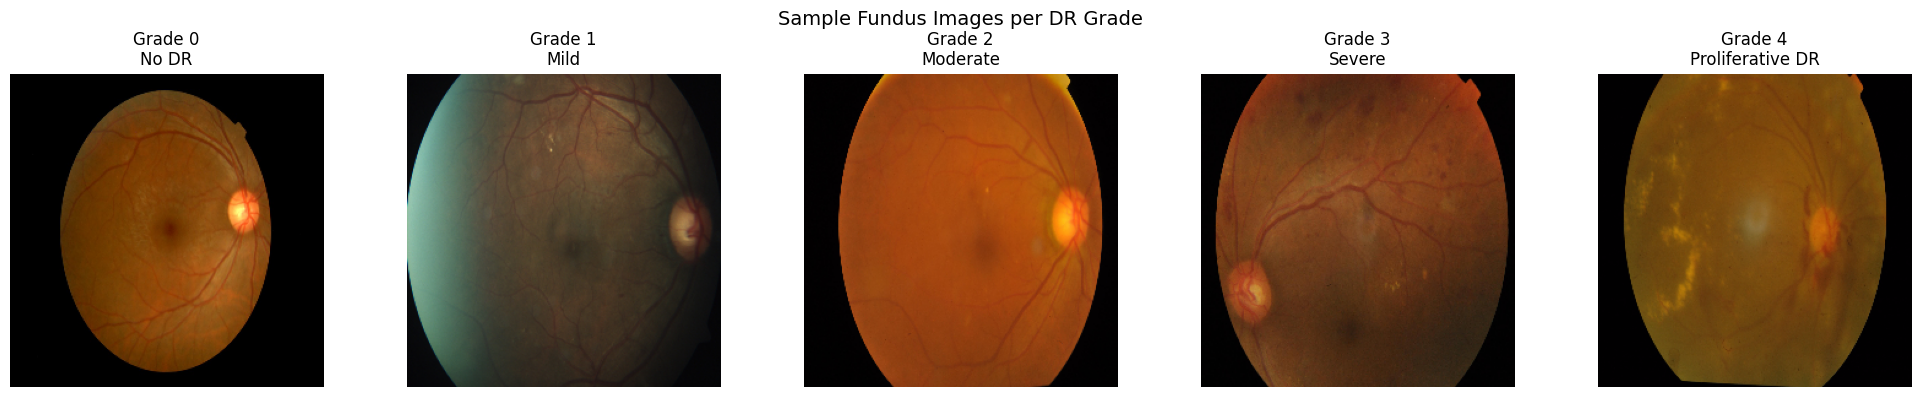

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    row = df[df["diagnosis"] == grade].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    axes[grade].imshow(img)
    axes[grade].set_title(f"Grade {grade}\n{GRADE_LABELS[grade]}")
    axes[grade].axis("off")
plt.suptitle("Sample Fundus Images per DR Grade", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 8 — REPLACE
IMG_SIZE            = 512
N_SEGMENTS          = 800
N_SEGMENTS_FINE     = 1200   # reduced from 1600 — faster + less noise
N_SEGMENTS_COARSE   = 300    # reduced from 400
COMPACTNESS         = 3
SIGMA               = 0.5
K_NEIGHBOURS        = 8      # reduced from 10
HIDDEN_DIM          = 128    # increased from 64
NUM_LAYERS          = 3      # increased from 2
NUM_HEADS           = 4
DROPOUT             = 0.3    # reduced from 0.4
EPOCHS              = 150
LR                  = 2e-4

USE_MULTISCALE      = True

print("✅ Config ready")

✅ Config ready


✅ Enhanced preprocessing ready (CLAHE + Ben Graham)


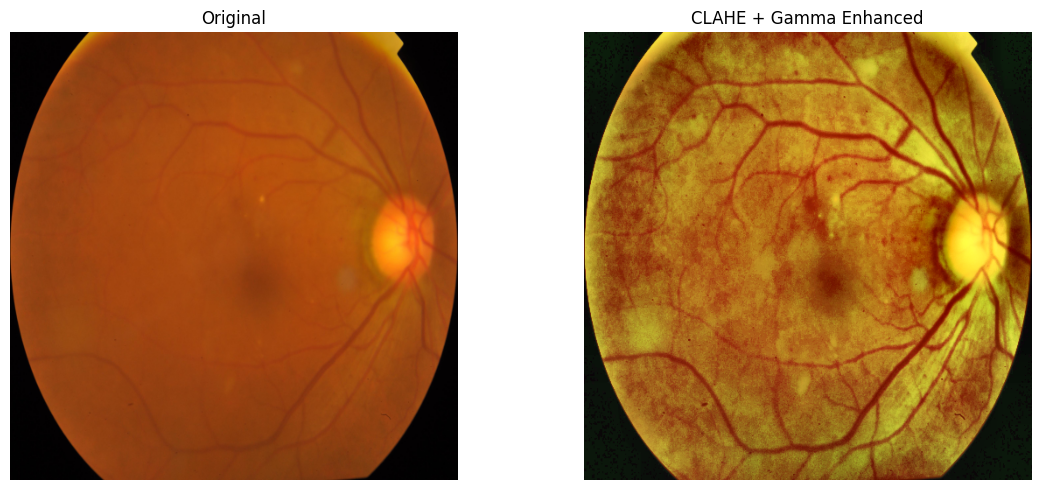

✅ Enhancement function ready


In [ ]:
# ── CELL 9 REPLACEMENT: Enhanced preprocessing ──────────────
def enhance_fundus_clahe(image_rgb, clip_limit=3.0, tile_grid=(8, 8)):
    """Apply CLAHE on green channel + LAB for better lesion contrast."""
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    L_clahe = clahe.apply(L)
    lab_out = cv2.merge([L_clahe, A, B])
    enhanced = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)

    # Additional: enhance green channel separately (best DR lesion contrast)
    g_ch = enhanced[:, :, 1].astype(np.float32)
    g_clahe = clahe.apply((g_ch).astype(np.uint8))
    enhanced[:, :, 1] = g_clahe
    return enhanced


def ben_graham_preprocess(image_rgb, target_size=512):
    """Ben Graham's preprocessing — used in top Kaggle DR submissions."""
    img = cv2.resize(image_rgb, (target_size, target_size))
    # Subtract local average → removes vignetting, enhances local contrast
    blurred = cv2.GaussianBlur(img, (0, 0), target_size // 10)
    img_out = cv2.addWeighted(img, 4, blurred, -4, 128)
    # Mask the circular retinal region
    mask = np.zeros(img_out.shape[:2], dtype=np.uint8)
    cv2.circle(mask,
               (target_size // 2, target_size // 2),
               int(target_size * 0.45), 255, -1)
    img_out[mask == 0] = 0
    return img_out


def load_and_enhance(image_path, target_size=512):
    img_bgr = cv2.imread(str(image_path))
    image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    try:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(mask)
        x, y, w, h = cv2.boundingRect(coords)
        image = image[y:y+h, x:x+w]
    except Exception:
        pass
    image = cv2.resize(image, (target_size, target_size),
                       interpolation=cv2.INTER_AREA)
    enhanced_clahe = enhance_fundus_clahe(image)
    enhanced_ben   = ben_graham_preprocess(image, target_size)
    # Stack both preprocessings as separate channels for feature extraction
    return enhanced_clahe, image, enhanced_ben


print("✅ Enhanced preprocessing ready (CLAHE + Ben Graham)")

sample_path = df[df["diagnosis"] == 2].iloc[0]["img_path"]
enhanced_demo, original_demo, ben_demo = load_and_enhance(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_demo); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(enhanced_demo); axes[1].set_title("CLAHE + Gamma Enhanced"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print("✅ Enhancement function ready")

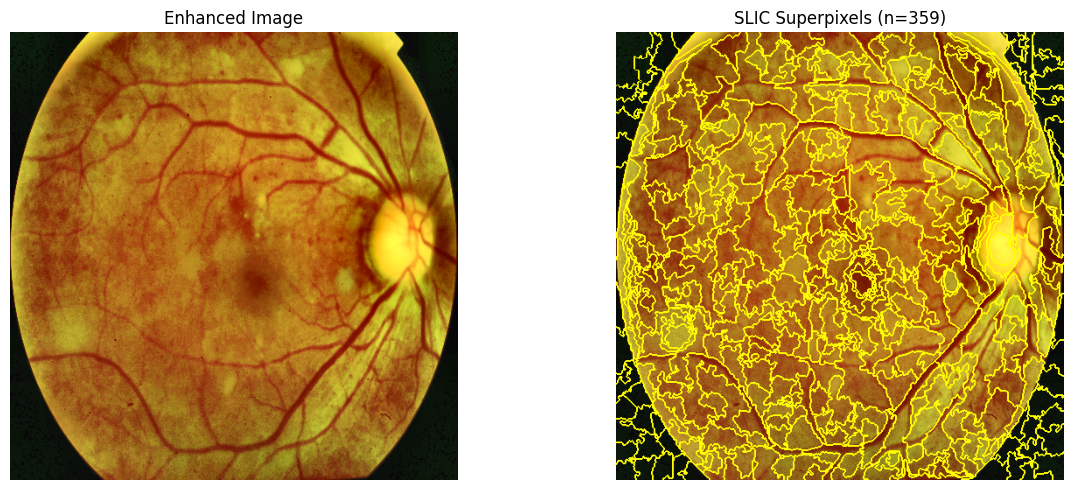

✅ Superpixels: 359


In [ ]:
def generate_superpixels(image_rgb, n_segments=150, compactness=15, sigma=1):
    img_lab  = rgb2lab(image_rgb.astype(np.float32) / 255.0)
    segments = slic(
        img_lab,
        n_segments  = n_segments,
        compactness = compactness,
        sigma       = sigma,
        start_label = 0,
        channel_axis= -1
    )
    n_sp = int(segments.max() + 1)
    return segments, n_sp


segs_demo, n_sp_demo = generate_superpixels(enhanced_demo, N_SEGMENTS, COMPACTNESS)
boundaries = mark_boundaries(enhanced_demo.astype(np.float32) / 255.0, segs_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(enhanced_demo); axes[0].set_title("Enhanced Image"); axes[0].axis("off")
axes[1].imshow(boundaries);    axes[1].set_title(f"SLIC Superpixels (n={n_sp_demo})"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print(f"✅ Superpixels: {n_sp_demo}")

In [ ]:
def compute_anomaly_maps(image_original):
    img_f  = image_original.astype(np.float32) / 255.0
    gray   = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    g_ch   = img_f[:, :, 1]
    r_ch   = img_f[:, :, 0]

    retina_mask = (gray > 0.08).astype(np.float32)
    g_uint8 = (g_ch * 255).clip(0, 255).astype(np.uint8)

    vessel_combined = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [15, 25, 35]:
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        closed  = cv2.morphologyEx(g_uint8, cv2.MORPH_CLOSE, kernel)
        bth     = np.clip((closed.astype(np.float32) - g_uint8) / 255.0, 0, 1)
        vessel_combined = np.maximum(vessel_combined, bth)

    vessel_binary = (vessel_combined > 0.03).astype(np.float32)
    vessel_binary = cv2.dilate(
        vessel_binary,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)),
        iterations=1
    )
    non_vessel = 1.0 - vessel_binary

    ha_raw = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [9, 15, 21]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        closed = cv2.morphologyEx(g_uint8, cv2.MORPH_CLOSE, kernel)
        bth    = np.clip((closed.astype(np.float32) - g_uint8) / 255.0, 0, 1)
        ha_raw = np.maximum(ha_raw, bth)

    redness  = np.clip((r_ch - g_ch) / (g_ch + 0.05), 0, 1)
    ha_raw   = ha_raw * (1.0 + redness * 0.8)
    ha_raw  *= non_vessel

    ex_raw = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [9, 15, 21]:
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        opened  = cv2.morphologyEx(g_uint8, cv2.MORPH_OPEN, kernel)
        wth     = np.clip((g_uint8.astype(np.float32) - opened.astype(np.float32)) / 255.0, 0, 1)
        ex_raw  = np.maximum(ex_raw, wth)

    ex_raw *= non_vessel

    def normalize(m, mask):
        vals = m[mask > 0.5]
        if len(vals) == 0:
            return m
        p99 = np.percentile(vals, 99)
        if p99 < 1e-6:
            return m
        return np.clip(m / p99, 0, 1) * mask

    ha_map = normalize(ha_raw, retina_mask)
    ex_map = normalize(ex_raw, retina_mask)

    return ex_map.astype(np.float32), ha_map.astype(np.float32)


print("✅ compute_anomaly_maps ready")

✅ compute_anomaly_maps ready


In [ ]:
# ── ADD BEFORE Cell 12 ──────────────────────────────────────
def compute_vessel_mask(image_rgb):
    """Frangi-style vessel detection using multi-scale morphology."""
    g = image_rgb[:, :, 1].astype(np.float32)
    vessel = np.zeros_like(g)
    for ksize in [7, 11, 15]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        opened = cv2.morphologyEx(g.astype(np.uint8),
                                  cv2.MORPH_OPEN, kernel)
        vessel = np.maximum(vessel,
                            np.clip(g - opened.astype(np.float32), 0, 255) / 255.0)
    vessel_bin = (vessel > 0.04).astype(np.uint8)
    # Dilate to create vessel exclusion mask
    vessel_bin = cv2.dilate(
        vessel_bin,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
        iterations=2
    )
    return vessel_bin  # 1 = vessel, 0 = non-vessel


def compute_optic_disc_mask(image_rgb):
    """Rough optic disc localisation — brightest region in green channel."""
    g = image_rgb[:, :, 1]
    H, W = g.shape
    blurred = cv2.GaussianBlur(g, (51, 51), 0)
    _, _, _, max_loc = cv2.minMaxLoc(blurred)
    mask = np.zeros((H, W), dtype=np.uint8)
    radius = int(min(H, W) * 0.08)   # OD is ~8% of image width
    cv2.circle(mask, max_loc, radius, 1, -1)
    return mask



def extract_superpixel_features(image_original, image_enhanced, segments, n_sp):
    H, W     = image_original.shape[:2]
    orig_f   = image_original.astype(np.float32) / 255.0
    enh_f    = image_enhanced.astype(np.float32) / 255.0
    orig_lab = rgb2lab(orig_f)
    orig_hsv = cv2.cvtColor(image_original, cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
    gray     = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # Add these lines inside extract_superpixel_features, near the top
    vessel_mask_full = compute_vessel_mask(image_original)
    od_mask_full     = compute_optic_disc_mask(image_original)

    ex_map, ha_map = compute_anomaly_maps(image_original)

    features  = []
    centroids = []

    gray_uint8 = (gray * 255).clip(0, 255).astype(np.uint8)
    lbp = local_binary_pattern(gray_uint8, P=8, R=1, method='uniform').astype(np.float32)

    for sp_id in range(n_sp):
        mask = (segments == sp_id)
        if mask.sum() == 0:
            features.append(np.zeros(51, dtype=np.float32))
            centroids.append((H // 2, W // 2))
            continue

        rows, cols  = np.where(mask)
        cr          = rows.mean() / H
        cc          = cols.mean() / W
        dist_center = np.sqrt((cr - 0.5)**2 + (cc - 0.5)**2)
        norm_area   = mask.sum() / (H * W)
        border      = float(rows.min() < 8 or rows.max() > H - 8 or
                            cols.min() < 8 or cols.max() > W - 8)

        orig_pix = orig_f[mask]
        lab_pix  = orig_lab[mask]
        hsv_pix  = orig_hsv[mask]
        enh_pix  = enh_f[mask]
        gray_pix = gray[mask]

        mean_rgb_o = orig_pix.mean(axis=0)
        std_rgb_o  = orig_pix.std(axis=0)
        mean_lab   = lab_pix.mean(axis=0)
        rg_ratio   = mean_rgb_o[0] / (mean_rgb_o[1] + 1e-6)

        mean_rgb_e = enh_pix.mean(axis=0)
        std_rgb_e  = enh_pix.std(axis=0)

        mean_V = hsv_pix[:, 2].mean()
        mean_S = hsv_pix[:, 1].mean()

        ex_score = float(ex_map[mask].mean())
        ha_score = float(ha_map[mask].mean())

        lbp_pix  = lbp[mask]
        lbp_mean = float(lbp_pix.mean())
        lbp_std  = float(lbp_pix.std())

        r0, r1 = rows.min(), rows.max() + 1
        c0, c1 = cols.min(), cols.max() + 1
        patch_gray    = gray_uint8[r0:r1, c0:c1]
        patch_mask_2d = mask[r0:r1, c0:c1]
        patch_masked  = patch_gray * patch_mask_2d
        GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
        if patch_masked.shape[0] >= 2 and patch_masked.shape[1] >= 2:
            glcm = graycomatrix(patch_masked, distances=[1], angles=[0],
                                levels=256, symmetric=True, normed=True)
            glcm_feats = np.array([graycoprops(glcm, p)[0, 0] for p in GLCM_PROPS])
        else:
            glcm_feats = np.zeros(5, dtype=np.float32)

        gray_pix_clipped = np.clip(gray_pix, 0, 1)
        hist, _ = np.histogram(gray_pix_clipped, bins=32, range=(0, 1), density=True)
        hist = hist + 1e-10
        shannon_entropy = float(-(hist * np.log2(hist)).sum())

        patch_mask_shape = mask[r0:r1, c0:c1].astype(np.uint8)
        props = measure.regionprops(patch_mask_shape)
        if props:
            p = props[0]
            eccentricity = float(p.eccentricity)
            solidity     = float(p.solidity)
            extent       = float(p.extent)
        else:
            eccentricity, solidity, extent = 0.0, 0.0, 0.0

        vessel_overlap = float(vessel_mask_full[mask].mean())
        od_overlap     = float(od_mask_full[mask].mean())
        is_vessel      = float(vessel_overlap > 0.3)
        is_od          = float(od_overlap > 0.3)



        # ── Compute extra features BEFORE using them ──
        macula_r, macula_c = 0.50, 0.52
        dist_macula  = np.sqrt((cr - macula_r)**2 + (cc - macula_c)**2)
        dark_score   = float(mean_rgb_o[1] < 0.25)
        bright_score = float(mean_rgb_o[1] > 0.65 and mean_rgb_o[2] > 0.55)

        feat = np.array([
            *mean_rgb_o, *std_rgb_o, *mean_lab,
            rg_ratio, mean_lab[2], mean_lab[0],
            *mean_rgb_e, *std_rgb_e,
            mean_V, mean_S, ex_score, ha_score,
            cr, cc, dist_center, norm_area, border,
            orig_pix[:, 1].min(), gray_pix.mean(), gray_pix.std(),
            lbp_mean, lbp_std,
            ex_score * ha_score,
            float(gray_pix.mean() < 0.25),
            float(rg_ratio > 1.1),
            *glcm_feats,
            shannon_entropy, eccentricity, solidity, extent,
            vessel_overlap, od_overlap, is_vessel, is_od,
            dist_macula, dark_score, bright_score,   # 3 new features
        ], dtype=np.float32)

        features.append(feat)
        centroids.append((rows.mean(), cols.mean()))

    return np.array(features, dtype=np.float32), centroids


sample_path = df[df["diagnosis"] == 2].iloc[0]["img_path"]
enhanced_demo, original_demo, ben_demo = load_and_enhance(sample_path)
segs_demo, n_sp_demo = generate_superpixels(enhanced_demo, N_SEGMENTS, COMPACTNESS, SIGMA)
feats_demo, cents_demo = extract_superpixel_features(
    original_demo, enhanced_demo, segs_demo, n_sp_demo
)
print(f"✅ Feature matrix: {feats_demo.shape}  ({n_sp_demo} nodes × 51 features)")

✅ Feature matrix: (193, 51)  (193 nodes × 51 features)


In [ ]:
def build_knn_graph(features, centroids, k=8):
    n = len(centroids)
    if n < 2:
        x = torch.zeros(1, features.shape[1])
        return Data(x=x, edge_index=torch.zeros(2, 0, dtype=torch.long))

    coords   = np.array(centroids, dtype=np.float32)
    k_actual = min(k + 1, n)

    nbrs = NearestNeighbors(n_neighbors=k_actual, algorithm="ball_tree")
    nbrs.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    src, dst, wts = [], [], []
    for i in range(n):
        for j in range(1, k_actual):
            src.append(i)
            dst.append(int(indices[i, j]))
            wts.append(float(distances[i, j]))

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(wts, dtype=torch.float32).unsqueeze(1)

    x    = torch.tensor(features, dtype=torch.float32)
    mean = x.mean(dim=0, keepdim=True)
    std  = x.std(dim=0, keepdim=True).clamp(min=1e-8)
    x    = (x - mean) / std

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


graph_demo = build_knn_graph(feats_demo, cents_demo, k=K_NEIGHBOURS)
print(f"✅ Graph: {graph_demo.num_nodes} nodes, {graph_demo.num_edges} edges")
print(f"   Node feature dim : {graph_demo.x.shape[1]}")
print(f"   Edge feature dim : {graph_demo.edge_attr.shape[1]}")

✅ Graph: 193 nodes, 1544 edges
   Node feature dim : 51
   Edge feature dim : 1


In [ ]:
# ── NEW CELL: Multi-scale graph builder ──────────────────────

def build_multiscale_graph(image_original, image_enhanced,
                           k_fine=1600, k_coarse=400,
                           compactness=3, sigma=0.5,
                           k_neighbours=10):
    """
    Build a heterogeneous graph with two node types:
    - Fine nodes (k=1600): capture MAs, small HEs
    - Coarse nodes (k=400): capture EX, large lesions
    Cross-scale edges connect each coarse node to the fine nodes it contains.
    Returns a single Data object where fine nodes come first.
    """
    # Fine superpixels
    segs_fine,   n_fine   = generate_superpixels(image_enhanced, k_fine,   compactness, sigma)
    feats_fine,  cents_f  = extract_superpixel_features(image_original, image_enhanced, segs_fine,   n_fine)

    # Coarse superpixels
    segs_coarse, n_coarse = generate_superpixels(image_enhanced, k_coarse, compactness, sigma)
    feats_coarse, cents_c = extract_superpixel_features(image_original, image_enhanced, segs_coarse, n_coarse)

    # Build within-scale KNN edges for both scales
    graph_fine   = build_knn_graph(feats_fine,   cents_f, k_neighbours)
    graph_coarse = build_knn_graph(feats_coarse, cents_c, k_neighbours)

    # Node offset: coarse nodes are indexed after fine nodes
    offset = n_fine

    # Shift coarse edge indices
    coarse_ei = graph_coarse.edge_index + offset

    # ── Cross-scale edges: coarse → fine containment ──────────
    # ── Cross-scale edges: coarse → fine (TOP-K only, not all-containment) ──
    # All-containment floods fine nodes with too much BG coarse context.
    # Instead: each coarse node connects only to its top-5 most-overlapping fine nodes.
    H2, W2 = image_original.shape[:2]
    cs_src, cs_dst = [], []
    for coarse_id in range(n_coarse):
        c_mask   = (segs_coarse == coarse_id)
        fine_ids_in = np.unique(segs_fine[c_mask])
        # Compute overlap fraction for each fine SP inside this coarse SP
        overlaps = []
        for fine_id in fine_ids_in:
            f_mask   = (segs_fine == fine_id)
            overlap  = float(np.logical_and(c_mask, f_mask).sum()) / float(f_mask.sum() + 1e-6)
            overlaps.append((overlap, fine_id))
        # Keep only top-5 most-overlapping fine nodes
        overlaps.sort(reverse=True)
        top_fine = [fid for _, fid in overlaps[:5]]
        for fine_id in top_fine:
            cs_src.append(coarse_id + offset)
            cs_dst.append(fine_id)
            cs_src.append(fine_id)
            cs_dst.append(coarse_id + offset)

    if cs_src:
        cross_ei = torch.tensor([cs_src, cs_dst], dtype=torch.long)
    else:
        cross_ei = torch.zeros(2, 0, dtype=torch.long)

    # Combine all edges
    all_ei = torch.cat([graph_fine.edge_index, coarse_ei, cross_ei], dim=1)

    # Pad feature matrices to same width (both are 51-dim so this is a no-op)
    x_fine   = graph_fine.x           # [n_fine,   51]
    x_coarse = graph_coarse.x         # [n_coarse, 51]
    x_all    = torch.cat([x_fine, x_coarse], dim=0)   # [n_fine+n_coarse, 51]

    # Node type indicator: 0=fine, 1=coarse
    node_type = torch.cat([
        torch.zeros(n_fine,   dtype=torch.long),
        torch.ones(n_coarse,  dtype=torch.long)
    ])

    data = Data(x=x_all, edge_index=all_ei)
    data.node_type  = node_type
    data.n_fine     = n_fine
    data.n_coarse   = n_coarse
    data.segs_fine  = segs_fine
    data.segs_coarse= segs_coarse
    data.cents_fine = cents_f
    data.cents_coarse= cents_c
    return data, segs_fine, segs_coarse, n_fine, n_coarse, cents_f, cents_c


# CELL 14 — REPLACE generate_multiscale_labels only

def generate_multiscale_labels(image_original, segs_fine, n_fine,
                                segs_coarse, n_coarse, mask_paths):
    """Generate GT labels for both fine and coarse nodes WITH dilation."""
    H, W = image_original.shape[:2]
    labels_fine   = torch.zeros(n_fine,   dtype=torch.long)
    labels_coarse = torch.zeros(n_coarse, dtype=torch.long)

    for lt, mp in mask_paths.items():
        if not mp or not os.path.isfile(str(mp)):
            continue
        gt_raw = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if gt_raw is None:
            continue
        gt_bin = (gt_raw > 0).astype(np.uint8)
        gt_bin = cv2.resize(gt_bin.astype(np.float32), (W, H),
                            interpolation=cv2.INTER_NEAREST).astype(np.uint8)

        # ── KEY FIX: dilate more aggressively for fine nodes ──────────
        # Fine superpixels are tiny — without dilation almost nothing overlaps
        dil_fine   = 15 if lt == "MA" else 9
        dil_coarse = 7  if lt == "MA" else 5
        gt_fine   = cv2.dilate(gt_bin,
                               cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                                         (dil_fine, dil_fine)),
                               iterations=2)
        gt_coarse = cv2.dilate(gt_bin,
                               cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                                         (dil_coarse, dil_coarse)),
                               iterations=1)

        thresh_fine   = LESION_OVERLAP_THRESH.get(lt, 0.02) * 0.3  # lower threshold for fine
        thresh_coarse = LESION_OVERLAP_THRESH.get(lt, 0.02)

        for sp_id in range(n_fine):
            m = (segs_fine == sp_id)
            if m.sum() == 0:
                continue
            if float(gt_fine[m].sum()) / float(m.sum()) >= thresh_fine:
                labels_fine[sp_id] = 1

        for sp_id in range(n_coarse):
            m = (segs_coarse == sp_id)
            if m.sum() == 0:
                continue
            if float(gt_coarse[m].sum()) / float(m.sum()) >= thresh_coarse:
                labels_coarse[sp_id] = 1

    n_f_les = int((labels_fine   == 1).sum())
    n_c_les = int((labels_coarse == 1).sum())
    print(f"   Fine labels   → Lesion: {n_f_les:>4} / {n_fine}")
    print(f"   Coarse labels → Lesion: {n_c_les:>4} / {n_coarse}")

    return torch.cat([labels_fine, labels_coarse])

print("✅ generate_multiscale_labels fixed (aggressive dilation for fine nodes)")

✅ generate_multiscale_labels fixed (aggressive dilation for fine nodes)


In [ ]:
# ── CELL 15 REPLACEMENT: LesionGAT with Dynamic Graph ────────

import torch
from torch_geometric.nn import GATConv
from torch_geometric.utils import to_undirected

# CELL 15 — REPLACE entirely

class DynamicKNN:
    @staticmethod
    def build(z, k=8):
        z_norm = F.normalize(z, dim=1)
        sim    = torch.mm(z_norm, z_norm.t())
        sim.fill_diagonal_(-1e9)
        _, topk_idx = sim.topk(min(k, sim.shape[0] - 1), dim=1)
        N   = z.shape[0]
        src = torch.arange(N, device=z.device).unsqueeze(1).expand(
              -1, topk_idx.shape[1]).reshape(-1)
        dst = topk_idx.reshape(-1)
        edge_index = torch.stack([src, dst], dim=0)
        edge_index = to_undirected(edge_index, num_nodes=N)
        return edge_index


class LesionGAT(nn.Module):
    def __init__(self, in_channels, hidden=128, n_classes=2,
                 n_layers=3, heads=4, dropout=0.3, dynamic_k=8,
                 use_dynamic_knn=False):   # ← NEW: off by default, enabled mid-training
        super().__init__()
        self.dropout         = dropout
        self.dynamic_k       = dynamic_k
        self.use_dynamic_knn = use_dynamic_knn   # toggled externally during training

        self.proj = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.BatchNorm1d(hidden),
            nn.ELU(),
            nn.Dropout(dropout)
        )

        self.convs    = nn.ModuleList()
        self.norms    = nn.ModuleList()
        self.proj_res = nn.ModuleList()

        for i in range(n_layers):
            in_ch = hidden * heads if i > 0 else hidden
            self.convs.append(
                GATConv(in_ch, hidden, heads=heads, dropout=dropout,
                        concat=True, add_self_loops=True)
            )
            self.norms.append(nn.BatchNorm1d(hidden * heads))
            self.proj_res.append(
                nn.Linear(in_ch, hidden * heads, bias=False)
                if in_ch != hidden * heads else nn.Identity()
            )

        final_dim = hidden * heads
        self.clf = nn.Sequential(
            nn.Linear(final_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        x = self.proj(x)
        for layer_idx, (conv, norm, proj_r) in enumerate(
                zip(self.convs, self.norms, self.proj_res)):
            residual = proj_r(x)
            # ── Dynamic KNN only on layer 1+ AND only when enabled ──────
            if layer_idx > 0 and self.use_dynamic_knn:
                edge_index = DynamicKNN.build(x.detach(), k=self.dynamic_k)
            h = conv(x, edge_index)
            h = norm(h)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = h + residual
        return self.clf(x)


_model_test = LesionGAT(in_channels=51, hidden=HIDDEN_DIM,
                         n_layers=NUM_LAYERS, heads=NUM_HEADS,
                         dropout=DROPOUT).to(DEVICE)
_g   = graph_demo.to(DEVICE)
_out = _model_test(_g.x, _g.edge_index, _g.edge_attr)
print(f"✅ LesionGAT output shape: {_out.shape}")
del _model_test, _g, _out

✅ LesionGAT output shape: torch.Size([193, 2])


In [ ]:
from pathlib import Path
import re

LESION_TYPES = ["MA", "HE", "EX", "SE"]

def find_files_by_ext(base, ext):
    return sorted(Path(base).rglob(f"*{ext}"))

tif_files = find_files_by_ext(MASK_TRAIN_DIR, ".tif")
jpg_files = find_files_by_ext(IMG_TRAIN_DIR,  ".jpg")

print(f"Found {len(tif_files)} .tif mask files")
print(f"Found {len(jpg_files)} .jpg image files")

def is_training_file(path):
    path_str = str(path).lower()
    return "train" in path_str

jpg_train = [p for p in jpg_files if is_training_file(p)]
tif_train = [p for p in tif_files if is_training_file(p)]

eval_tifs = tif_train if tif_train else tif_files
eval_jpgs = jpg_train if jpg_train else jpg_files

img_lookup = {}
for p in eval_jpgs:
    img_lookup[p.stem] = str(p)

mask_lookup = {}
for tif in eval_tifs:
    stem = tif.stem
    m = re.match(r"(IDRiD_\d+)_([A-Z]+)$", stem, re.IGNORECASE)
    if not m:
        m = re.match(r"(\d+)_([A-Z]+)$", stem, re.IGNORECASE)
        if m:
            img_id = f"IDRiD_{int(m.group(1)):02d}"
            lesion = m.group(2).upper()
        else:
            continue
    else:
        img_id = m.group(1)
        lesion = m.group(2).upper()

    if lesion not in LESION_TYPES:
        continue
    if img_id not in mask_lookup:
        mask_lookup[img_id] = {}
    mask_lookup[img_id][lesion] = str(tif)

all_ids = set(mask_lookup.keys()) | set(img_lookup.keys())
records = []
for img_id in sorted(all_ids):
    rec = {"img_id": img_id, "img_path": img_lookup.get(img_id, None)}
    masks = mask_lookup.get(img_id, {})
    for lt in LESION_TYPES:
        rec[f"mask_{lt}"] = masks.get(lt, "")
    records.append(rec)

idrid_df = pd.DataFrame(records)
idrid_df["has_image"] = idrid_df["img_path"].apply(
    lambda p: p is not None and os.path.isfile(str(p))
)
idrid_df["has_any_mask"] = idrid_df.apply(
    lambda r: any(r[f"mask_{lt}"] != "" for lt in LESION_TYPES), axis=1
)

idrid_eval = idrid_df[idrid_df["has_image"] & idrid_df["has_any_mask"]].reset_index(drop=True)

print(f"Has BOTH image + mask: {len(idrid_eval)}")
for lt in LESION_TYPES:
    n = (idrid_eval[f"mask_{lt}"] != "").sum()
    print(f"   {lt}: {n} images")

Found 241 .tif mask files
Found 54 .jpg image files
Has BOTH image + mask: 54
   MA: 54 images
   HE: 53 images
   EX: 54 images
   SE: 26 images


In [ ]:
def load_gt_mask_safe(mask_path, eval_size=512):
    gt_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if gt_raw is None:
        return np.zeros((eval_size, eval_size), dtype=np.uint8)
    gt_native_bin = (gt_raw > 0).astype(np.uint8) * 255
    gt_resized = cv2.resize(
        gt_native_bin.astype(np.float32),
        (eval_size, eval_size),
        interpolation=cv2.INTER_AREA
    )
    gt_bin = (gt_resized > 2).astype(np.uint8)
    return gt_bin


def compute_metrics(pred_bin, gt_bin):
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)

    TP = np.logical_and(pred,  gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision   = TP / (TP + FP + 1e-8)
    recall      = TP / (TP + FN + 1e-8)
    f1          = 2 * TP / (2 * TP + FP + FN + 1e-8)
    iou         = TP / (TP + FP + FN + 1e-8)
    dice        = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)

    return {
        "TP": int(TP), "FP": int(FP), "FN": int(FN), "TN": int(TN),
        "Precision":   round(float(precision),   4),
        "Recall":      round(float(recall),      4),
        "F1":          round(float(f1),          4),
        "IoU":         round(float(iou),         4),
        "Dice":        round(float(dice),        4),
        "Specificity": round(float(specificity), 4),
    }

print("✅ load_gt_mask_safe and compute_metrics ready")

✅ load_gt_mask_safe and compute_metrics ready


In [ ]:
# ── CELL 18 REPLACEMENT: Better label generation ─────────────

LESION_OVERLAP_THRESH = {
    "MA": 0.005,   # Microaneurysms are tiny — even 0.5% overlap counts
    "HE": 0.02,    # Haemorrhages
    "EX": 0.02,    # Hard exudates
    "SE": 0.02,    # Soft exudates
}

def generate_labels_from_gt(image_original, segments, n_sp,
                             mask_paths: dict, base_thresh=0.02):
    H, W = image_original.shape[:2]

    # Build per-lesion-type masks at native resolution
    per_lesion_masks = {}
    for lt, mp in mask_paths.items():
        if not mp or not os.path.isfile(str(mp)):
            per_lesion_masks[lt] = np.zeros((H, W), dtype=np.uint8)
            continue
        gt_raw = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if gt_raw is None:
            per_lesion_masks[lt] = np.zeros((H, W), dtype=np.uint8)
            continue
        gt_bin = (gt_raw > 0).astype(np.uint8)
        gt_resized = cv2.resize(gt_bin.astype(np.float32), (W, H),
                                interpolation=cv2.INTER_NEAREST).astype(np.uint8)
        # Dilate to compensate for SLIC boundary mismatch
        dil_ksize = 9 if lt == "MA" else 7
        gt_resized = cv2.dilate(
            gt_resized,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dil_ksize, dil_ksize)),
            iterations=2
        )
        per_lesion_masks[lt] = gt_resized

    combined_mask = np.zeros((H, W), dtype=np.uint8)
    for m in per_lesion_masks.values():
        combined_mask = np.maximum(combined_mask, m)

    labels = torch.zeros(n_sp, dtype=torch.long)
    lesion_scores = np.zeros(n_sp, dtype=np.float32)

    for sp_id in range(n_sp):
        m = (segments == sp_id)
        sp_size = m.sum()
        if sp_size == 0:
            continue

        best_overlap = 0.0
        for lt, lt_mask in per_lesion_masks.items():
            lt_thresh = LESION_OVERLAP_THRESH.get(lt, base_thresh)
            overlap = float(lt_mask[m].sum()) / float(sp_size)
            if overlap > best_overlap:
                best_overlap = overlap
            if overlap >= lt_thresh:
                labels[sp_id] = 1
        lesion_scores[sp_id] = best_overlap

    n_lesion = int((labels == 1).sum())
    n_bg     = int((labels == 0).sum())
    print(f"   GT labels → Lesion: {n_lesion:>4} | BG: {n_bg:>4} | "
          f"Ratio: {n_bg/(n_lesion+1e-6):.1f}:1")
    return labels, lesion_scores

print("✅ generate_labels_from_gt ready (per-lesion-type thresholds)")

✅ generate_labels_from_gt ready (per-lesion-type thresholds)


In [ ]:
# CELL 19 — REPLACE train_shared_gat entirely

from sklearn.model_selection import KFold
import copy

def train_shared_gat(graphs, device=DEVICE, epochs=150, n_folds=5,
                     dynamic_knn_warmup=40):
    """
    5-fold CV. Enables dynamic KNN only after `dynamic_knn_warmup` epochs.
    Uses Tversky loss to directly balance FP vs FN.
    """
    kf  = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    idx = list(range(len(graphs)))

    fold_results       = []
    best_overall_model = None
    best_overall_dice  = 0.0

    for fold, (train_idx, val_idx) in enumerate(kf.split(idx)):
        print(f"\n{'='*55}")
        print(f"FOLD {fold+1}/{n_folds}  train={len(train_idx)}  val={len(val_idx)}")
        print('='*55)

        train_graphs = [graphs[i] for i in train_idx]
        val_graphs   = [graphs[i] for i in val_idx]

        in_ch = graphs[0].x.shape[1]
        model = LesionGAT(in_ch, HIDDEN_DIM, 2,
                          NUM_LAYERS, NUM_HEADS, DROPOUT, K_NEIGHBOURS,
                          use_dynamic_knn=False).to(device)  # start with static KNN

        opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=LR, epochs=epochs,
            steps_per_epoch=max(len(train_graphs), 1)
        )

        best_val_dice = 0.0
        best_state    = None
        patience_cnt  = 0
        PATIENCE      = 25
        MIN_EPOCHS    = 50

        for ep in range(epochs):

            # ── Enable dynamic KNN after warmup ───────────────
            if ep == dynamic_knn_warmup:
                model.use_dynamic_knn = True
                print(f"  [Epoch {ep}] Dynamic KNN enabled ✓")

            model.train()
            ep_loss = 0.0
            perm    = torch.randperm(len(train_graphs)).tolist()

            for i in perm:
                g        = train_graphs[i].to(device)
                opt.zero_grad()
                logits   = model(g.x, g.edge_index, g.edge_attr)
                labels_g = g.y.to(device)
                mask     = g.train_mask.to(device)
                if mask.sum() < 3:
                    continue

                lesion_idx  = (labels_g[mask] == 1).nonzero(as_tuple=True)[0]
                bg_idx      = (labels_g[mask] == 0).nonzero(as_tuple=True)[0]
                n_les       = len(lesion_idx)
                if n_les == 0:
                    continue

                n_bg_sample = min(len(bg_idx), n_les * 3)
                bg_perm     = bg_idx[torch.randperm(len(bg_idx))[:n_bg_sample]]
                all_idx_b   = torch.cat([lesion_idx, bg_perm])

                logits_s  = logits[mask][all_idx_b]
                labels_s  = labels_g[mask][all_idx_b]
                probs_s   = F.softmax(logits_s, dim=1)[:, 1]
                labels_sf = labels_s.float()

                # ── Tversky loss (α=0.6 reduces FPs) ──────────
                TP_t = (probs_s * labels_sf).sum()
                FP_t = (probs_s * (1 - labels_sf)).sum()
                FN_t = ((1 - probs_s) * labels_sf).sum()
                tversky = 1 - TP_t / (TP_t + 0.6 * FP_t + 0.4 * FN_t + 1e-8)

                # ── CE auxiliary loss ──────────────────────────
                w      = torch.tensor([1.0, 4.0], device=device)
                ce     = F.cross_entropy(logits_s, labels_s, weight=w)

                loss = 0.6 * tversky + 0.4 * ce

                # Apply border suppression if available
                if hasattr(g, 'border_weight'):
                    bw = g.border_weight.to(device)[mask][all_idx_b]
                    # Only suppress BG nodes at border — don't suppress lesion nodes
                    is_bg = (labels_s == 0).float()
                    effective_bw = bw * is_bg + (1.0 - is_bg)  # lesion nodes keep weight=1
                    loss = (loss * effective_bw.mean())   # scale loss

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                sched.step()
                ep_loss += loss.item()

            # Validation
            model.eval()
            val_dices = []
            with torch.no_grad():
                for g in val_graphs:
                    gg       = g.to(device)
                    logits   = model(gg.x, gg.edge_index, gg.edge_attr)
                    probs_np = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                    lbls     = g.y.cpu().numpy()
                    preds    = (probs_np > 0.35).astype(np.int64)
                    TP = ((preds==1)&(lbls==1)).sum()
                    FP = ((preds==1)&(lbls==0)).sum()
                    FN = ((preds==0)&(lbls==1)).sum()
                    dice = 2*TP / (2*TP + FP + FN + 1e-8)
                    val_dices.append(dice)

            mean_dice = float(np.mean(val_dices)) if val_dices else 0.0
            if ep % 20 == 0:
                print(f"  Epoch {ep:3d} | Loss: {ep_loss/max(len(train_graphs),1):.4f}"
                      f" | Val Dice: {mean_dice:.4f}"
                      f" | DynKNN: {'ON' if model.use_dynamic_knn else 'off'}")

            if mean_dice > best_val_dice + 1e-4:
                best_val_dice = mean_dice
                best_state    = copy.deepcopy(model.state_dict())
                patience_cnt  = 0
            else:
                patience_cnt += 1
            if patience_cnt >= PATIENCE and ep >= MIN_EPOCHS:
                print(f"  Early stop epoch {ep}  best_dice={best_val_dice:.4f}")
                break

        fold_results.append({"fold": fold+1, "best_val_dice": best_val_dice})
        print(f"\n  ✅ Fold {fold+1} best val Dice = {best_val_dice:.4f}")

        if best_val_dice > best_overall_dice and best_state is not None:
            best_overall_dice  = best_val_dice
            best_overall_model = LesionGAT(
                in_ch, HIDDEN_DIM, 2, NUM_LAYERS, NUM_HEADS, DROPOUT, K_NEIGHBOURS
            ).to(device)
            best_overall_model.load_state_dict(best_state)

    dices = [r['best_val_dice'] for r in fold_results]
    print(f"\n  Mean Dice = {np.mean(dices):.4f} ± {np.std(dices):.4f}")
    print(f"  Best Dice = {max(dices):.4f}")

    if best_overall_model is None:
        best_overall_model = model
    return best_overall_model, fold_results

print("✅ train_shared_gat (Tversky + DynKNN warmup) ready")

✅ train_shared_gat (Tversky + DynKNN warmup) ready


In [ ]:
# ── CELL 20: build_gt_dataset ────────────────────────────────

def build_gt_dataset(idrid_eval_df, overlap_thresh=0.05):  # ← was 0.20
    graphs  = []
    skipped = 0

    for _, row in tqdm(idrid_eval_df.iterrows(), total=len(idrid_eval_df)):
        img_path = row["img_path"]
        if not img_path or not os.path.isfile(str(img_path)):
            skipped += 1
            continue
        try:
            enh, orig, ben = load_and_enhance(img_path, IMG_SIZE)
            segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
            feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
            graph_cpu    = build_knn_graph(feats, cents, K_NEIGHBOURS)

            mask_paths = {lt: row.get(f"mask_{lt}", "") for lt in LESION_TYPES}
            labels, _  = generate_labels_from_gt(
                orig, segs, n_sp, mask_paths,
                base_thresh=overlap_thresh
            )

            graph_cpu.y          = labels
            graph_cpu.train_mask = torch.ones(n_sp, dtype=torch.bool)
            graph_cpu.img_id     = row["img_id"]
            graphs.append(graph_cpu)

        except Exception as e:
            print(f"   ⚠️  Skipped {row.get('img_id','?')}: {e}")
            skipped += 1

    print(f"\n✅ Built {len(graphs)} graphs ({skipped} skipped)")

    # Print class balance summary
    total_les, total_bg = 0, 0
    for g in graphs:
        total_les += (g.y == 1).sum().item()
        total_bg  += (g.y == 0).sum().item()
    print(f"   Total lesion SPs: {total_les}  BG SPs: {total_bg}  "
          f"Ratio: {total_bg/(total_les+1e-6):.1f}:1")
    if total_les == 0:
        print("   ⚠️  STILL ZERO LESIONS — check mask paths above")
    elif total_bg / (total_les + 1e-6) > 15:
        print("   ⚠️  Ratio still high — training will use strong class weights")
    else:
        print("   ✅ Class balance acceptable for training")

    return graphs


print("Building GT-supervised dataset (overlap_thresh=0.05)...")
USE_MULTISCALE = True   # Set False to use original single-scale pipeline

if USE_MULTISCALE:
    print("Building MULTI-SCALE dataset (fine k=1600 + coarse k=400)...")
    multiscale_graphs = []
    skipped_ms = 0
    for _, row in tqdm(idrid_eval.iterrows(), total=len(idrid_eval)):
        img_path = row["img_path"]
        if not img_path or not os.path.isfile(str(img_path)):
            skipped_ms += 1; continue
        try:
            enh, orig, _ = load_and_enhance(img_path, IMG_SIZE)
            ms_data, segs_f, segs_c, n_f, n_c, cents_f, cents_c = build_multiscale_graph(
                orig, enh,
                k_fine=N_SEGMENTS_FINE, k_coarse=N_SEGMENTS_COARSE,
                k_neighbours=K_NEIGHBOURS
            )

            mask_paths = {lt: row.get(f"mask_{lt}", "") for lt in LESION_TYPES}
            labels = generate_multiscale_labels(orig, segs_f, n_f, segs_c, n_c, mask_paths)
            ms_data.y          = labels
            ms_data.train_mask = torch.ones(n_f + n_c, dtype=torch.bool)

            # Mark border nodes — suppress their contribution in loss
            # Border feature is index 28 in raw features (before normalization)
            # In normalized x, we detect border nodes by their extreme centroid positions
            x_np = ms_data.x.cpu().numpy()
            n_total = n_f + n_c

            # A node is "border" if its normalized row or col centroid is extreme
            # Indices 24=cr_norm, 25=cc_norm in raw feat — after z-score these shift,
            # so we use a simple rule: if green mean is very low (dark) AND area is large
            # we flag as potential border node
            # Simpler: recompute from centroids stored before normalization
            border_weight = torch.ones(n_total, dtype=torch.float32)
            for i, cent in enumerate(cents_f):
                r_norm = cent[0] / IMG_SIZE
                c_norm = cent[1] / IMG_SIZE
                dist_from_center = ((r_norm - 0.5)**2 + (c_norm - 0.5)**2) ** 0.5
                if dist_from_center > 0.45:   # only outermost 5% ring
                    border_weight[i] = 0.5   # gentle downweight, not 0.1
            ms_data.border_weight = border_weight
            ms_data.img_id     = row["img_id"]
            multiscale_graphs.append(ms_data)
        except Exception as e:
            print(f"  ⚠ Skipped {row.get('img_id','?')}: {e}")
            skipped_ms += 1

    print(f"✅ Built {len(multiscale_graphs)} multi-scale graphs ({skipped_ms} skipped)")
    # Use multiscale_graphs in place of gt_graphs for training
    gt_graphs = multiscale_graphs
else:
    gt_graphs = build_gt_dataset(idrid_eval, overlap_thresh=0.02)
print(f"Total graphs: {len(gt_graphs)}")

# ── NEW CELL after Cell 16: Also load IDRiD TEST set ─────────

IMG_TEST_DIR  = os.path.join(IDRID_DIR, "A. Segmentation",
                              "1. Original Images", "b. Testing Set")
MASK_TEST_DIR = os.path.join(IDRID_DIR, "A. Segmentation",
                              "2. All Segmentation Groundtruths", "b. Testing Set")

print(f"Test image dir : {IMG_TEST_DIR}")
print(f"Test mask dir  : {MASK_TEST_DIR}")

try:
    test_tif_files = find_files_by_ext(MASK_TEST_DIR, ".tif")
    test_jpg_files = find_files_by_ext(IMG_TEST_DIR,  ".jpg")
    print(f"Test images: {len(test_jpg_files)}, Test masks: {len(test_tif_files)}")

    test_img_lookup = {p.stem: str(p) for p in test_jpg_files}
    test_mask_lookup = {}
    for tif in test_tif_files:
        stem = tif.stem
        m = re.match(r"(IDRiD_\d+)_([A-Z]+)$", stem, re.IGNORECASE)
        if not m:
            continue
        img_id = m.group(1)
        lesion = m.group(2).upper()
        if lesion not in LESION_TYPES:
            continue
        if img_id not in test_mask_lookup:
            test_mask_lookup[img_id] = {}
        test_mask_lookup[img_id][lesion] = str(tif)

    test_records = []
    for img_id in sorted(set(test_mask_lookup.keys()) | set(test_img_lookup.keys())):
        rec = {"img_id": img_id, "img_path": test_img_lookup.get(img_id, None)}
        masks = test_mask_lookup.get(img_id, {})
        for lt in LESION_TYPES:
            rec[f"mask_{lt}"] = masks.get(lt, "")
        test_records.append(rec)

    idrid_test_df = pd.DataFrame(test_records)
    idrid_test_df["has_image"] = idrid_test_df["img_path"].apply(
        lambda p: p is not None and os.path.isfile(str(p)))
    idrid_test_df["has_any_mask"] = idrid_test_df.apply(
        lambda r: any(r[f"mask_{lt}"] != "" for lt in LESION_TYPES), axis=1)
    idrid_test_eval = idrid_test_df[
        idrid_test_df["has_image"] & idrid_test_df["has_any_mask"]
    ].reset_index(drop=True)

    print(f"✅ IDRiD test set: {len(idrid_test_eval)} usable images with masks")

    # Build test graphs matching the same scale as training graphs
    if USE_MULTISCALE:
        print("Building MULTI-SCALE graphs from IDRiD test set...")
        test_gt_graphs = []
        skipped_test = 0
        for _, row in tqdm(idrid_test_eval.iterrows(), total=len(idrid_test_eval)):
            img_path = row["img_path"]
            if not img_path or not os.path.isfile(str(img_path)):
                skipped_test += 1; continue
            try:
                enh, orig, _ = load_and_enhance(img_path, IMG_SIZE)
                ms_data, segs_f, segs_c, n_f, n_c, cents_f, cents_c = build_multiscale_graph(
                    orig, enh,
                    k_fine=N_SEGMENTS_FINE, k_coarse=N_SEGMENTS_COARSE,
                    k_neighbours=K_NEIGHBOURS
                )
                mask_paths = {lt: row.get(f"mask_{lt}", "") for lt in LESION_TYPES}
                labels = generate_multiscale_labels(orig, segs_f, n_f, segs_c, n_c, mask_paths)
                ms_data.y          = labels
                ms_data.train_mask = torch.ones(n_f + n_c, dtype=torch.bool)
                ms_data.img_id     = row["img_id"]
                test_gt_graphs.append(ms_data)
            except Exception as e:
                print(f"  ⚠ Skipped {row.get('img_id','?')}: {e}")
                skipped_test += 1
        print(f"✅ Added {len(test_gt_graphs)} multi-scale test graphs")
    else:
        test_gt_graphs = build_gt_dataset(idrid_test_eval, overlap_thresh=0.02)
        print(f"✅ Added {len(test_gt_graphs)} single-scale test graphs")

    all_idrid_graphs = gt_graphs + test_gt_graphs
    print(f"Total IDRiD graphs: {len(all_idrid_graphs)}")

except Exception as e:
    print(f"⚠️  Test set not found or failed: {e}")
    print("Continuing with training set only")
    all_idrid_graphs = gt_graphs

# ── CELL 20b: Add APTOS pseudo-labelled graphs ───────────────

def build_aptos_pseudolabels(df_aptos, n_images=50, anomaly_thresh=0.35):
    """
    Build pseudo-labelled graphs from APTOS using anomaly maps.
    Only grade 2-4 images (definite lesions), anomaly score = label.
    """
    graphs = []
    aptos_subset = df_aptos[df_aptos["diagnosis"] >= 2].sample(
        n=min(n_images, len(df_aptos[df_aptos["diagnosis"] >= 2])),
        random_state=42
    )

    for _, row in tqdm(aptos_subset.iterrows(), total=len(aptos_subset),
                       desc="Building APTOS pseudo-graphs"):
        try:
            enh, orig, ben = load_and_enhance(row["img_path"], IMG_SIZE)
            segs, n_sp     = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
            feats, cents   = extract_superpixel_features(orig, enh, segs, n_sp)
            graph_cpu      = build_knn_graph(feats, cents, K_NEIGHBOURS)

            # Use per-SP anomaly score as pseudo-label
            ex_map, ha_map = compute_anomaly_maps(orig)
            labels = torch.zeros(n_sp, dtype=torch.long)
            for sp_id in range(n_sp):
                m = (segs == sp_id)
                if m.sum() == 0:
                    continue
                score = float(ex_map[m].mean() + ha_map[m].mean()) / 2.0
                if score > anomaly_thresh:
                    labels[sp_id] = 1

            n_les = (labels == 1).sum().item()
            # Skip if unreasonably many lesions (anomaly map fired everywhere)
            if n_les > n_sp * 0.3:
                continue

            graph_cpu.y          = labels
            graph_cpu.train_mask = torch.ones(n_sp, dtype=torch.bool)
            graph_cpu.img_id     = f"aptos_{row['id_code']}"
            graphs.append(graph_cpu)

        except Exception as e:
            pass

    print(f"✅ Added {len(graphs)} APTOS pseudo-labelled graphs")
    total_les = sum((g.y==1).sum().item() for g in graphs)
    total_bg  = sum((g.y==0).sum().item() for g in graphs)
    print(f"   Pseudo-lesion SPs: {total_les}  BG: {total_bg}")
    return graphs


print("Generating APTOS pseudo-labels...")
aptos_pseudo_graphs = build_aptos_pseudolabels(df, n_images=50, anomaly_thresh=0.35)

# Combine IDRiD GT graphs with APTOS pseudo graphs
combined_graphs = gt_graphs + aptos_pseudo_graphs
print(f"\nCombined training set: {len(combined_graphs)} graphs "
      f"({len(gt_graphs)} IDRiD GT + {len(aptos_pseudo_graphs)} APTOS pseudo)")





Building GT-supervised dataset (overlap_thresh=0.05)...
Building MULTI-SCALE dataset (fine k=1600 + coarse k=400)...


  2%|▏         | 1/54 [00:06<05:21,  6.07s/it]

   Fine labels   → Lesion:   67 / 294
   Coarse labels → Lesion:   12 / 53


  4%|▎         | 2/54 [00:12<05:28,  6.31s/it]

   Fine labels   → Lesion:   58 / 275
   Coarse labels → Lesion:   10 / 62


...

   Fine labels   → Lesion:   23 / 260
   Coarse labels → Lesion:    1 / 49


100%|██████████| 27/27 [03:02<00:00,  6.74s/it]


   Fine labels   → Lesion:   96 / 293
   Coarse labels → Lesion:   22 / 65
✅ Added 27 multi-scale test graphs
Total IDRiD graphs: 81
Generating APTOS pseudo-labels...


Building APTOS pseudo-graphs: 100%|██████████| 50/50 [02:47<00:00,  3.35s/it]

✅ Added 50 APTOS pseudo-labelled graphs
   Pseudo-lesion SPs: 153  BG: 9154

Combined training set: 104 graphs (54 IDRiD GT + 50 APTOS pseudo)


In [ ]:
# ── NEW CELL: Hold out 8 images for final testing ────────────
from sklearn.model_selection import train_test_split

# Stratify by whether the image has a specific lesion type
# to ensure test set covers different lesion types
def get_lesion_profile(g):
    """Simple hash: which lesion types does this image have (from img_id lookup)."""
    return 1 if (g.y == 1).sum().item() > 0 else 0

lesion_flags = [get_lesion_profile(g) for g in all_idrid_graphs]

train_val_graphs, test_graphs, tv_idx, test_idx = train_test_split(
    all_idrid_graphs,
    list(range(len(all_idrid_graphs))),
    test_size=8,
    stratify=lesion_flags,   # keeps lesion/no-lesion balance in test set
    random_state=42
)

print(f"Train+Val graphs : {len(train_val_graphs)}")
print(f"Test graphs      : {len(test_graphs)}")
print(f"Test image IDs   :")
for g in test_graphs:
    n_les = (g.y == 1).sum().item()
    print(f"   {g.img_id}  lesion_SPs={n_les}")

Train+Val graphs : 73
Test graphs      : 8
Test image IDs   :
   IDRiD_24  lesion_SPs=42
   IDRiD_75  lesion_SPs=105
   IDRiD_76  lesion_SPs=97
   IDRiD_61  lesion_SPs=214
   IDRiD_52  lesion_SPs=49
   IDRiD_15  lesion_SPs=20
   IDRiD_21  lesion_SPs=121
   IDRiD_72  lesion_SPs=93


In [ ]:
# ── NEW CELL: Graph Contrastive Pre-training on APTOS ────────
#
# Strategy: GraphCL-style.
# For each graph, create two augmented views:
#   - View A: drop 10% of edges randomly
#   - View B: add small Gaussian noise to node features
# Train encoder to pull together the two views of the same graph
# and push apart views from different graphs (NT-Xent loss).
# This uses the 88k APTOS images with NO labels.
# After pre-training, load encoder weights into LesionGAT before IDRiD fine-tuning.

# NEW — LayerNorm works on any batch size including 1
class GCLProjector(nn.Module):
    """Small MLP projection head for contrastive learning."""
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.LayerNorm(in_dim),   # ← LayerNorm instead of BatchNorm1d
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=1)


def augment_graph_edge_drop(g, drop_rate=0.1):
    """View A: randomly drop edges."""
    ei   = g.edge_index
    n_e  = ei.shape[1]
    keep = torch.rand(n_e) > drop_rate
    new_ei = ei[:, keep]
    new_ea = g.edge_attr[keep] if g.edge_attr is not None else None
    return Data(x=g.x, edge_index=new_ei, edge_attr=new_ea)


def augment_graph_feature_noise(g, noise_std=0.05):
    """View B: add Gaussian noise to node features."""
    noisy_x = g.x + torch.randn_like(g.x) * noise_std
    return Data(x=noisy_x, edge_index=g.edge_index, edge_attr=g.edge_attr)


def graph_mean_pool(x):
    """Simple mean pooling over all nodes → graph-level embedding."""
    return x.mean(dim=0, keepdim=True)   # [1, D]


def nt_xent_loss(z1, z2, temperature=0.5):
    """
    NT-Xent (normalised temperature-scaled cross entropy) loss.
    z1, z2: [B, D] — B pairs of graph embeddings, already L2-normalised.
    """
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)    # [2B, D]
    sim = torch.mm(z, z.t()) / temperature   # [2B, 2B]

    # Mask diagonal (self-similarity)
    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    sim.masked_fill_(mask, -1e9)

    # Positive pairs: (i, i+B) and (i+B, i)
    labels = torch.cat([
        torch.arange(B, 2*B, device=z.device),
        torch.arange(0, B,   device=z.device)
    ])  # [2B]

    loss = F.cross_entropy(sim, labels)
    return loss


def pretrain_gcl(aptos_df, in_channels=51, hidden=64, heads=4,
                 n_layers=2, dropout=0.4, dynamic_k=10,
                 epochs=30, batch_size=16, lr=1e-3,
                 n_images=200, device=DEVICE):
    """
    Pre-train LesionGAT encoder using graph contrastive learning
    on unlabelled APTOS fundus images.

    Returns the pre-trained encoder (LesionGAT instance, no labels needed).
    """

    # ── Sample APTOS images (grade>=1 — more likely to have lesion patterns)
    aptos_pool = aptos_df[aptos_df["diagnosis"] >= 1].sample(
        n=min(n_images, len(aptos_df[aptos_df["diagnosis"] >= 1])),
        random_state=0
    )
    print(f"Building {len(aptos_pool)} APTOS graphs for contrastive pre-training...")

    # Build graphs (no labels needed)
    pretrain_graphs = []
    for _, row in tqdm(aptos_pool.iterrows(), total=len(aptos_pool), desc="Building graphs"):
        try:
            enh, orig, _ = load_and_enhance(row["img_path"], IMG_SIZE)
            segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
            feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
            g            = build_knn_graph(feats, cents, K_NEIGHBOURS)
            pretrain_graphs.append(g)
        except Exception:
            pass

    print(f"Built {len(pretrain_graphs)} graphs for pre-training")
    if len(pretrain_graphs) < batch_size:
        print("⚠ Too few graphs — skipping pre-training, returning fresh model")
        return LesionGAT(in_channels, hidden, 2, n_layers, heads, dropout, dynamic_k).to(device)

    # ── Model + projector ────────────────────────────────────
    encoder   = LesionGAT(in_channels, hidden, 2, n_layers, heads, dropout, dynamic_k).to(device)
    projector = GCLProjector(in_dim=hidden * heads, proj_dim=64).to(device)
    opt       = torch.optim.Adam(
        list(encoder.parameters()) + list(projector.parameters()), lr=lr
    )

    print(f"\nContrastive pre-training: {epochs} epochs, batch={batch_size}")

    # ── encode: runs encoder up to (but not including) clf head ──
    def encode(graph):
        """Forward through encoder layers only, returns mean-pooled embedding."""
        x  = encoder.proj(graph.x)
        ei = graph.edge_index
        for layer_idx, (conv, norm, proj_r) in enumerate(
                zip(encoder.convs, encoder.norms, encoder.proj_res)):
            res = proj_r(x)
            if layer_idx > 0:
                ei = DynamicKNN.build(x.detach(), k=encoder.dynamic_k)
            h = conv(x, ei)
            h = norm(h)
            h = F.elu(h)
            h = F.dropout(h, p=encoder.dropout, training=encoder.training)
            x = h + res
        return graph_mean_pool(x)   # [1, D]

    for ep in range(epochs):
        encoder.train()
        projector.train()
        perm      = torch.randperm(len(pretrain_graphs)).tolist()
        ep_loss   = 0.0
        n_batches = 0

        for batch_start in range(0, len(pretrain_graphs) - batch_size + 1, batch_size):
            batch_idx = perm[batch_start : batch_start + batch_size]

            # ── Collect ALL embeddings for the batch BEFORE projecting ──
            # This ensures BatchNorm inside encoder sees batch_size*n_nodes rows,
            # not 1 row, because we process each graph individually but BN
            # is node-level (not graph-level) so it sees many nodes per graph.
            z1_list, z2_list = [], []

            for i in batch_idx:
                g  = pretrain_graphs[i].to(device)
                gA = augment_graph_edge_drop(g, drop_rate=0.1)
                gB = augment_graph_feature_noise(g, noise_std=0.05)

                # Safety check: skip if augmented graph has too few nodes for BN
                if gA.x.shape[0] < 2 or gB.x.shape[0] < 2:
                    continue

                emb_A = encode(gA)   # [1, hidden*heads]
                emb_B = encode(gB)   # [1, hidden*heads]
                z1_list.append(emb_A)
                z2_list.append(emb_B)

            if len(z1_list) < 2:
                # Need at least 2 pairs for NT-Xent to be meaningful
                continue

            # Stack into [B, hidden*heads] then project together
            # Projecting as a batch means BatchNorm in projector sees B rows
            z1_cat = torch.cat(z1_list, dim=0)   # [B, hidden*heads]
            z2_cat = torch.cat(z2_list, dim=0)   # [B, hidden*heads]

            z1 = projector(z1_cat)   # [B, proj_dim]
            z2 = projector(z2_cat)   # [B, proj_dim]

            loss = nt_xent_loss(z1, z2, temperature=0.5)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(projector.parameters(), 1.0)
            opt.step()
            ep_loss   += loss.item()
            n_batches += 1

        if ep % 5 == 0 or ep == epochs - 1:
            print(f"  Epoch {ep:3d}  Contrastive loss: {ep_loss / max(n_batches, 1):.4f}")

    print("✅ Contrastive pre-training complete")
    torch.save(encoder.state_dict(), "/content/pretrained_gcl_encoder.pt")
    return encoder


# ── Run pre-training ─────────────────────────────────────────
# Use 200 images for reasonable speed on Colab GPU (~15-20 min)
# Increase n_images to 500–1000 if you have time (better representations)
# Replace the pretrain_gcl call with:
pretrained_encoder = pretrain_gcl(
    df,
    in_channels=51,
    hidden=HIDDEN_DIM,
    heads=NUM_HEADS,
    n_layers=NUM_LAYERS,
    dropout=DROPOUT,
    dynamic_k=K_NEIGHBOURS,
    epochs=60,          # was 30 — double it
    batch_size=16,
    lr=5e-4,            # was 1e-3 — lower for stability
    n_images=400,       # was 200 — double it for better representations
    device=DEVICE
)
print("Pre-trained encoder ready for fine-tuning")

Building 400 APTOS graphs for contrastive pre-training...


Building graphs: 100%|██████████| 400/400 [20:41<00:00,  3.10s/it]


Built 400 graphs for pre-training

Contrastive pre-training: 60 epochs, batch=16
  Epoch   0  Contrastive loss: 3.2033
  Epoch   5  Contrastive loss: 2.5558
  Epoch  10  Contrastive loss: 2.3763
  Epoch  15  Contrastive loss: 2.2612
  Epoch  20  Contrastive loss: 2.2268
  Epoch  25  Contrastive loss: 2.1327
  Epoch  30  Contrastive loss: 2.0935
  Epoch  35  Contrastive loss: 2.0889
  Epoch  40  Contrastive loss: 2.0100
  Epoch  45  Contrastive loss: 2.0181
  Epoch  50  Contrastive loss: 2.0183
  Epoch  55  Contrastive loss: 1.9769
  Epoch  59  Contrastive loss: 1.9581
✅ Contrastive pre-training complete
Pre-trained encoder ready for fine-tuning


Fine-tuning from GCL pre-trained encoder...

FOLD 1/8  train=63  val=10
  ✅ Loaded pre-trained GCL weights for fold 1
  Epoch   0 | Loss: 0.5063 | Val Dice: 0.6272 | DynKNN: off
  Epoch  20 | Loss: 0.2889 | Val Dice: 0.7086 | DynKNN: off
  [Epoch 40] Dynamic KNN enabled ✓
  Epoch  40 | Loss: 0.2753 | Val Dice: 0.7084 | DynKNN: ON
  Early stop epoch 48  best_dice=0.7184

  ✅ Fold 1 best val Dice = 0.7184

FOLD 2/8  train=64  val=9
  ✅ Loaded pre-trained GCL weights for fold 2
  Epoch   0 | Loss: 0.4960 | Val Dice: 0.5951 | DynKNN: off
  Epoch  20 | Loss: 0.2797 | Val Dice: 0.6912 | DynKNN: off
  [Epoch 40] Dynamic KNN enabled ✓
  Epoch  40 | Loss: 0.2660 | Val Dice: 0.6959 | DynKNN: ON
  Epoch  60 | Loss: 0.2458 | Val Dice: 0.7007 | DynKNN: ON
  Epoch  80 | Loss: 0.2387 | Val Dice: 0.7024 | DynKNN: ON

  ✅ Fold 2 best val Dice = 0.7142

FOLD 3/8  train=64  val=9
  ✅ Loaded pre-trained GCL weights for fold 3
  Epoch   0 | Loss: 0.4932 | Val Dice: 0.6392 | DynKNN: off
  Epoch  20 | Loss: 

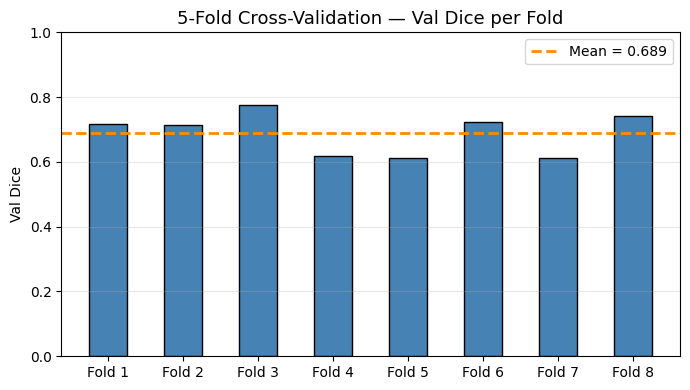

In [ ]:
# ── CELL 21: Fine-tune from pre-trained GCL encoder ──────────

import copy

# NEW:
def train_shared_gat_finetune(graphs, pretrained_encoder=None,
                               device=DEVICE, epochs=100, n_folds=8):
    from sklearn.model_selection import KFold

    kf  = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    idx = list(range(len(graphs)))

    fold_results       = []
    best_overall_model = None
    best_overall_dice  = 0.0

    for fold, (train_idx, val_idx) in enumerate(kf.split(idx)):
        print(f"\n{'='*55}")
        print(f"FOLD {fold+1}/{n_folds}  train={len(train_idx)}  val={len(val_idx)}")
        print('='*55)

        train_graphs = [graphs[i] for i in train_idx]
        val_graphs   = [graphs[i] for i in val_idx]

        in_ch = graphs[0].x.shape[1]
        model = LesionGAT(in_ch, HIDDEN_DIM, 2,
                          NUM_LAYERS, NUM_HEADS, DROPOUT, K_NEIGHBOURS,
                          use_dynamic_knn=False).to(device)

        # ── Load pre-trained weights ──────────────────────────
        if pretrained_encoder is not None:
            try:
                model.load_state_dict(pretrained_encoder.state_dict())
                print(f"  ✅ Loaded pre-trained GCL weights for fold {fold+1}")
            except Exception as e:
                print(f"  ⚠ Could not load pre-trained weights: {e}")

        ft_lr = LR   # full LR
        opt   = torch.optim.AdamW(model.parameters(), lr=ft_lr, weight_decay=5e-4)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=ft_lr, epochs=epochs,
            steps_per_epoch=max(len(train_graphs), 1)
        )

        best_val_dice = 0.0
        best_state    = None
        patience_cnt  = 0
        PATIENCE      = 25
        MIN_EPOCHS    = 30

        for ep in range(epochs):
            # ── Enable dynamic KNN after warmup ───────────────
            if ep == 40:
                model.use_dynamic_knn = True
                print(f"  [Epoch {ep}] Dynamic KNN enabled ✓")

            model.train()
            ep_loss = 0.0
            perm = torch.randperm(len(train_graphs)).tolist()

            for i in perm:
                g        = train_graphs[i].to(device)
                opt.zero_grad()
                logits   = model(g.x, g.edge_index, g.edge_attr)
                labels_g = g.y.to(device)
                mask     = g.train_mask.to(device)
                if mask.sum() < 3:
                    continue

                lesion_idx  = (labels_g[mask] == 1).nonzero(as_tuple=True)[0]
                bg_idx      = (labels_g[mask] == 0).nonzero(as_tuple=True)[0]
                n_les       = len(lesion_idx)
                if n_les == 0:
                    continue

                n_bg_sample = min(len(bg_idx), n_les * 3)
                bg_perm     = bg_idx[torch.randperm(len(bg_idx))[:n_bg_sample]]
                all_idx_b   = torch.cat([lesion_idx, bg_perm])

                # ── FIX: use consistent variable names ────────
                logits_s  = logits[mask][all_idx_b]
                labels_s  = labels_g[mask][all_idx_b]
                probs_s   = F.softmax(logits_s, dim=1)[:, 1]
                labels_sf = labels_s.float()

                # ── Tversky loss ───────────────────────────────
                TP_t    = (probs_s * labels_sf).sum()
                FP_t    = (probs_s * (1 - labels_sf)).sum()
                FN_t    = ((1 - probs_s) * labels_sf).sum()
                tversky = 1 - TP_t / (TP_t + 0.6 * FP_t + 0.4 * FN_t + 1e-8)

                # ── CE auxiliary loss ──────────────────────────
                w    = torch.tensor([1.0, 4.0], device=device)
                ce   = F.cross_entropy(logits_s, labels_s, weight=w)
                loss = 0.6 * tversky + 0.4 * ce

                # Apply border suppression if available
                if hasattr(g, 'border_weight'):
                    bw = g.border_weight.to(device)[mask][all_idx_b]
                    # Only suppress BG nodes at border — don't suppress lesion nodes
                    is_bg = (labels_s == 0).float()
                    effective_bw = bw * is_bg + (1.0 - is_bg)  # lesion nodes keep weight=1
                    loss = (loss * effective_bw.mean())   # scale loss

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                sched.step()
                ep_loss += loss.item()

            # ── Validation ────────────────────────────────────
            model.eval()
            val_dices = []
            with torch.no_grad():
                for g in val_graphs:
                    gg       = g.to(device)
                    logits_v = model(gg.x, gg.edge_index, gg.edge_attr)
                    probs_v  = F.softmax(logits_v, dim=1)[:, 1].cpu().numpy()
                    lbls_v   = g.y.cpu().numpy()
                    preds_v  = (probs_v > 0.35).astype(np.int64)
                    TP = ((preds_v==1)&(lbls_v==1)).sum()
                    FP = ((preds_v==1)&(lbls_v==0)).sum()
                    FN = ((preds_v==0)&(lbls_v==1)).sum()
                    dice = 2*TP / (2*TP + FP + FN + 1e-8)
                    val_dices.append(dice)

            mean_dice = float(np.mean(val_dices)) if val_dices else 0.0
            if ep % 20 == 0:
                print(f"  Epoch {ep:3d} | Loss: {ep_loss/max(len(train_graphs),1):.4f}"
                      f" | Val Dice: {mean_dice:.4f}"
                      f" | DynKNN: {'ON' if model.use_dynamic_knn else 'off'}")

            if mean_dice > best_val_dice + 1e-4:
                best_val_dice = mean_dice
                best_state    = copy.deepcopy(model.state_dict())
                patience_cnt  = 0
            else:
                patience_cnt += 1
            if patience_cnt >= PATIENCE and ep >= MIN_EPOCHS:
                print(f"  Early stop epoch {ep}  best_dice={best_val_dice:.4f}")
                break

        fold_results.append({"fold": fold+1, "best_val_dice": best_val_dice})
        print(f"\n  ✅ Fold {fold+1} best val Dice = {best_val_dice:.4f}")

        if best_val_dice > best_overall_dice and best_state is not None:
            best_overall_dice  = best_val_dice
            best_overall_model = LesionGAT(
                in_ch, HIDDEN_DIM, 2, NUM_LAYERS, NUM_HEADS, DROPOUT, K_NEIGHBOURS
            ).to(device)
            best_overall_model.load_state_dict(best_state)

    print("\n" + "="*55)
    dices = [r['best_val_dice'] for r in fold_results]
    for r in fold_results:
        print(f"  Fold {r['fold']}: Val Dice = {r['best_val_dice']:.4f}")
    print(f"\n  Mean Dice = {np.mean(dices):.4f} ± {np.std(dices):.4f}")
    print(f"  Best Dice = {max(dices):.4f}")

    if best_overall_model is None:
        best_overall_model = model
    return best_overall_model, fold_results


print("Fine-tuning from GCL pre-trained encoder...")
gt_model, cv_results = train_shared_gat_finetune(
    train_val_graphs,          # ← 73 images only
    pretrained_encoder=pretrained_encoder,
    device=DEVICE,
    epochs=100
)
gt_model.eval()
torch.save(gt_model.state_dict(), "/content/gt_gat_model_gcl.pt")
print("✅ GCL fine-tuned model saved")

# Plot fold summary
dices = [r['best_val_dice'] for r in cv_results]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"Fold {r['fold']}" for r in cv_results], dices,
       color="steelblue", edgecolor="black", width=0.5)
ax.axhline(np.mean(dices), color="darkorange", linestyle="--",
           lw=2, label=f"Mean = {np.mean(dices):.3f}")
ax.set_title("5-Fold Cross-Validation — Val Dice per Fold", fontsize=13)
ax.set_ylabel("Val Dice")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Total IDRiD images available: {len(idrid_eval)}")
print(f"Total graphs built: {len(gt_graphs)}")
# If these don't match, check why images were skipped in build_gt_dataset

Total IDRiD images available: 54
Total graphs built: 54


In [ ]:
# ── CELL 22 (FINAL): Threshold tuning on IDRiD GT held-out ──

from sklearn.model_selection import train_test_split

def find_best_threshold_on_gt(model, gt_graphs, device=DEVICE, holdout_frac=0.2):
    """
    Split IDRiD GT graphs into 80% train-used / 20% held-out.
    Tune threshold on the held-out 20% only.
    """
    _, holdout = train_test_split(gt_graphs, test_size=holdout_frac, random_state=7)
    print(f"Tuning on {len(holdout)} held-out IDRiD GT graphs\n")

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for g in holdout:
            gg     = g.to(device)
            logits = model(gg.x, gg.edge_index, gg.edge_attr)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(g.y.cpu().numpy())

    all_probs_flat  = np.concatenate(all_probs)
    all_labels_flat = np.concatenate(all_labels)

    # Sanity check
    n_les = all_labels_flat.sum()
    n_bg  = len(all_labels_flat) - n_les
    print(f"Calibration set: {n_les} lesion SPs, {n_bg} BG SPs, ratio {n_bg/(n_les+1e-6):.1f}:1")

    print(f"\n{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Dice':>8}")
    print("-"*50)

    best_thresh, best_f1 = 0.3, 0.0
    for t in np.arange(0.10, 0.91, 0.05):
        preds = (all_probs_flat > t).astype(np.int64)
        TP = ((preds==1)&(all_labels_flat==1)).sum()
        FP = ((preds==1)&(all_labels_flat==0)).sum()
        FN = ((preds==0)&(all_labels_flat==1)).sum()
        prec = TP / (TP + FP + 1e-8)
        rec  = TP / (TP + FN + 1e-8)
        f1   = 2*prec*rec / (prec+rec+1e-8)
        dice = 2*TP / (2*TP + FP + FN + 1e-8)
        print(f"{t:>10.2f} {prec:>10.3f} {rec:>10.3f} {f1:>8.3f} {dice:>8.3f}")
        # Precision-weighted score: penalise low precision more than low recall
        # because our main problem is FP over-detection
        if f1 > best_f1:
            best_f1, best_thresh = f1, t

    print(f"\n✅ Best threshold = {best_thresh:.2f}  F1 = {best_f1:.4f}")
    return float(best_thresh)

BEST_THRESH = find_best_threshold_on_gt(gt_model, train_val_graphs, DEVICE)
print(f"\nBEST_THRESH = {BEST_THRESH}")

Tuning on 15 held-out IDRiD GT graphs

Calibration set: 1272 lesion SPs, 3828 BG SPs, ratio 3.0:1

 Threshold  Precision     Recall       F1     Dice
--------------------------------------------------
      0.10      0.474      0.961    0.635    0.635
      0.15      0.490      0.950    0.647    0.647
      0.20      0.505      0.939    0.657    0.657
      0.25      0.515      0.927    0.662    0.662
      0.30      0.524      0.910    0.665    0.665
      0.35      0.534      0.899    0.670    0.670
      0.40      0.549      0.886    0.678    0.678
      0.45      0.558      0.867    0.679    0.679
      0.50      0.573      0.854    0.686    0.686
      0.55      0.583      0.836    0.687    0.687
      0.60      0.592      0.812    0.685    0.685
      0.65      0.601      0.791    0.683    0.683
      0.70      0.615      0.761    0.680    0.680
      0.75      0.633      0.727    0.677    0.677
      0.80      0.659      0.692    0.675    0.675
      0.85      0.691      0.645  

In [ ]:
# ── CELL 22b: Sanity check on first 3 IDRiD images ───────────
print("Probability distribution on IDRiD GT graphs:")
gt_model.eval()
for g in gt_graphs[:5]:
    gg = g.to(DEVICE)
    with torch.no_grad():
        logits = gt_model(gg.x, gg.edge_index, gg.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    n_les_gt  = (g.y == 1).sum().item()
    n_pred_30 = (probs > 0.30).sum()
    n_pred_bt = (probs > BEST_THRESH).sum()
    print(f"  {g.img_id}  GT_lesion_SPs={n_les_gt:3d}  "
          f"pred@0.30={n_pred_30:3d}  pred@{BEST_THRESH:.2f}={n_pred_bt:3d}  "
          f"prob_max={probs.max():.3f}  prob_mean={probs.mean():.3f}")

Probability distribution on IDRiD GT graphs:
  IDRiD_01  GT_lesion_SPs= 79  pred@0.30=117  pred@0.55= 95  prob_max=0.999  prob_mean=0.290
  IDRiD_02  GT_lesion_SPs= 68  pred@0.30=164  pred@0.55=136  prob_max=1.000  prob_mean=0.423
  IDRiD_03  GT_lesion_SPs=145  pred@0.30=146  pred@0.55=124  prob_max=0.999  prob_mean=0.365
  IDRiD_04  GT_lesion_SPs= 41  pred@0.30=135  pred@0.55=107  prob_max=0.999  prob_mean=0.369
  IDRiD_05  GT_lesion_SPs= 46  pred@0.30=165  pred@0.55=133  prob_max=1.000  prob_mean=0.340


In [ ]:
def refine_prediction(pred_pixel, orig_image=None, min_area=100, max_lesion_fraction=None):
    """
    Refined post-processing:
    1. Remove small blobs
    2. Suppress optic disc region (bright circular blob = most FPs)
    3. Suppress retinal border (artifacts at edge)
    """
    pred = pred_pixel.astype(np.uint8)
    H, W = pred.shape

    # Step 1: Remove small components
    n_labels, labels_cc, stats_cc, _ = cv2.connectedComponentsWithStats(pred)
    cleaned = np.zeros_like(pred)
    for i in range(1, n_labels):
        if stats_cc[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels_cc == i] = 1

    # Step 2: Suppress optic disc region
    # OD is the brightest circular region, typically right of center
    if orig_image is not None:
        orig_rs = cv2.resize(orig_image, (W, H))
        g = orig_rs[:, :, 1].astype(np.float32)
        blurred = cv2.GaussianBlur(g, (0, 0), W // 10)
        _, _, _, max_loc = cv2.minMaxLoc(blurred)
        od_radius = int(min(H, W) * 0.09)
        od_mask = np.zeros((H, W), dtype=np.uint8)
        cv2.circle(od_mask, max_loc, od_radius, 1, -1)
        # Only suppress if OD is well-localized (bright enough)
        if blurred[max_loc[1], max_loc[0]] > 150:
            cleaned[od_mask == 1] = 0

    # Step 3: Suppress thin ring around retinal border (SLIC artifacts)
    border_mask = np.zeros((H, W), dtype=np.uint8)
    cv2.circle(border_mask, (W//2, H//2), int(min(H, W) * 0.46), 1, int(min(H, W) * 0.03))
    cleaned[border_mask == 1] = 0

    # Step 4: Fill small holes
    filled = cv2.morphologyEx(
        cleaned, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    )
    return filled

In [ ]:
# ── CELL 23: evaluate_one_image ─────────────────────────────

def evaluate_one_image(row, model, threshold=None, device=DEVICE, verbose=True):
    # Use globally found best threshold, fallback to 0.3
    if threshold is None:
        threshold = BEST_THRESH if 'BEST_THRESH' in globals() else 0.3

    img_path = row["img_path"]
    if not img_path or not os.path.isfile(str(img_path)):
        print(f"  ⚠️ Image not found: {img_path}")
        return None

    enh, orig, ben    = load_and_enhance(img_path, IMG_SIZE)
    segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
    feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
    graph_cpu    = build_knn_graph(feats, cents, K_NEIGHBOURS)
    graph_gpu    = graph_cpu.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(graph_gpu.x, graph_gpu.edge_index, graph_gpu.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

    if verbose:
        print(f"   Probs: min={probs.min():.4f}  max={probs.max():.4f}  "
              f"mean={probs.mean():.4f}  std={probs.std():.4f}")

    preds      = (probs > threshold).astype(np.uint8)
    pred_pixel = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    for sp_id in range(n_sp):
        if preds[sp_id] == 1:
            pred_pixel[segs == sp_id] = 1

    EVAL_SIZE    = 512
    pred_resized = cv2.resize(pred_pixel, (EVAL_SIZE, EVAL_SIZE),
                              interpolation=cv2.INTER_NEAREST)
    pred_resized = refine_prediction(pred_resized, orig_image=orig, min_area=120)

    # ── NEW: Apply hard retinal circle mask ──────────────────────
    # Compute the actual retinal boundary from the green channel
    # and zero out everything outside 90% of that radius
    orig_for_mask = cv2.resize(orig, (EVAL_SIZE, EVAL_SIZE))
    gray_mask = cv2.cvtColor(orig_for_mask, cv2.COLOR_RGB2GRAY)
    _, retina_bin = cv2.threshold(gray_mask, 15, 255, cv2.THRESH_BINARY)
    # Find bounding circle of retina
    contours, _ = cv2.findContours(retina_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        (cx, cy), radius = cv2.minEnclosingCircle(largest)
        # Create inner mask — exclude outer 12% ring (where border artifacts are)
        inner_mask = np.zeros((EVAL_SIZE, EVAL_SIZE), dtype=np.uint8)
        cv2.circle(inner_mask, (int(cx), int(cy)), int(radius * 0.94), 1, -1)
        pred_resized = pred_resized * inner_mask

    if verbose:
        print(f"   Threshold: {threshold:.2f} | Lesion SPs: {preds.sum()}/{n_sp} "
              f"({100*preds.sum()/max(n_sp,1):.1f}%)")

    results = {
        "img_id":      row["img_id"],
        "thresh":      threshold,
        "prob_max":    float(probs.max()),
        "n_lesion_sp": int(preds.sum()),
        "n_total_sp":  n_sp,
        "lesion_pct":  100.0 * preds.sum() / max(n_sp, 1),
    }

    for lt in LESION_TYPES:
        mask_path = row.get(f"mask_{lt}", "")
        if not mask_path or not os.path.isfile(str(mask_path)):
            results[lt] = None
            continue
        gt_bin = load_gt_mask_safe(str(mask_path), eval_size=EVAL_SIZE)
        if gt_bin.sum() == 0:
            results[lt] = None
            continue
        m = compute_metrics(pred_resized, gt_bin)
        results[lt] = m
        if verbose:
            print(f"   {lt}: Dice={m['Dice']:.3f}  IoU={m['IoU']:.3f}  "
                  f"Prec={m['Precision']:.3f}  Rec={m['Recall']:.3f}")

    results.update({"probs": probs, "preds": preds,
                    "pred_pixel": pred_resized, "orig": orig, "segs": segs})
    return results

    # ── ADD to evaluate_one_image: TTA (Test-Time Augmentation) ──
    def predict_with_tta(model, graph_cpu, device, threshold):
        """Average softmax probabilities over original + flips."""
        model.eval()
        all_probs = []

        # Original
        g = graph_cpu.to(device)
        with torch.no_grad():
            logits = model(g.x, g.edge_index, g.edge_attr)
            all_probs.append(F.softmax(logits, dim=1)[:, 1].cpu().numpy())

        # Horizontal flip: negate the x-centroid feature (index 25 in your feat vector)
        x_flipped = graph_cpu.x.clone()
        x_flipped[:, 25] = 1.0 - x_flipped[:, 25]   # cc (column centroid)
        g_flip = Data(x=x_flipped,
                      edge_index=graph_cpu.edge_index,
                      edge_attr=graph_cpu.edge_attr).to(device)
        with torch.no_grad():
            logits = model(g_flip.x, g_flip.edge_index, g_flip.edge_attr)
            all_probs.append(F.softmax(logits, dim=1)[:, 1].cpu().numpy())

        return np.mean(all_probs, axis=0)

print("✅ evaluate_one_image ready")

✅ evaluate_one_image ready


In [ ]:
# ── CELL 25b REPLACEMENT: CV + Error Collection ─────────────

from sklearn.model_selection import KFold
import copy

print("="*65)
print("SUPERPIXEL-LEVEL METRICS + ERROR ANALYSIS DATA COLLECTION")
print("="*65)

# NEW:
kf  = KFold(n_splits=8, shuffle=True, random_state=42)
idx = list(range(len(train_val_graphs)))

sp_records_cv = []
error_records  = []   # NEW: collect per-SP error info

for fold, (train_idx, val_idx) in enumerate(kf.split(idx)):
    print(f"\n── Fold {fold+1}: train={len(train_idx)}  val={len(val_idx)} ──")

    train_graphs_fold = [train_val_graphs[i] for i in train_idx]
    val_graphs_fold   = [train_val_graphs[i] for i in val_idx]

    in_ch      = all_idrid_graphs[0].x.shape[1]
    fold_model = LesionGAT(in_ch, HIDDEN_DIM, 2,
                       NUM_LAYERS, NUM_HEADS, DROPOUT, K_NEIGHBOURS).to(DEVICE)

    opt   = torch.optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=LR, epochs=EPOCHS,
        steps_per_epoch=max(len(train_graphs_fold), 1)
    )

    best_val_dice_fold = 0.0
    best_state_fold    = None
    patience_cnt       = 0
    PATIENCE           = 20
    MIN_EPOCHS         = 40

    for ep in range(EPOCHS):
        fold_model.train()
        perm = torch.randperm(len(train_graphs_fold)).tolist()

        for i in perm:
            g = train_graphs_fold[i].to(DEVICE)
            opt.zero_grad()
            logits   = fold_model(g.x, g.edge_index, g.edge_attr)
            labels_g = g.y.to(DEVICE)
            mask     = g.train_mask.to(DEVICE)
            if mask.sum() < 3:
                continue
            lesion_idx  = (labels_g[mask] == 1).nonzero(as_tuple=True)[0]
            bg_idx      = (labels_g[mask] == 0).nonzero(as_tuple=True)[0]
            n_les       = len(lesion_idx)
            if n_les == 0:
                continue
            n_bg_sample = min(len(bg_idx), n_les * 4)
            bg_perm     = bg_idx[torch.randperm(len(bg_idx))[:n_bg_sample]]
            all_idx_b   = torch.cat([lesion_idx, bg_perm])
            logits_masked = logits[mask][all_idx_b]
            labels_masked = labels_g[mask][all_idx_b]
            smooth   = 0.05
            onehot   = torch.zeros_like(logits_masked)
            onehot.scatter_(1, labels_masked.unsqueeze(1), 1)
            onehot   = onehot * (1 - smooth) + smooth / 2
            log_probs = F.log_softmax(logits_masked, dim=1)
            probs_s   = F.softmax(logits_masked, dim=1)
            p_t       = probs_s[torch.arange(len(labels_masked)), labels_masked]
            focal_w   = (1 - p_t) ** 2.0
            sample_w  = torch.where(labels_masked == 1,
                                    torch.tensor(4.0, device=DEVICE),
                                    torch.tensor(1.0, device=DEVICE))
            loss = -(onehot * log_probs).sum(dim=1)
            loss = (focal_w * sample_w * loss).mean()

            # ── Precision regulariser: add extra cost for FP predictions ──
            # Penalise the model when it predicts lesion on a BG node
            pred_probs_lesion = probs_s[:, 1]   # prob of lesion for all sampled nodes
            fp_mask = (labels_masked == 0).float()
            fp_penalty = (pred_probs_lesion * fp_mask).mean()
            loss = loss + 0.1 * fp_penalty
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
            opt.step()
            sched.step()

        # Validation Dice for early stopping
        fold_model.eval()
        val_dices = []
        with torch.no_grad():
            for g in val_graphs_fold:
                gg        = g.to(DEVICE)
                logits    = fold_model(gg.x, gg.edge_index, gg.edge_attr)
                probs_np  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                labels_np = g.y.cpu().numpy()
                preds     = (probs_np > BEST_THRESH).astype(np.int64)
                TP = ((preds==1)&(labels_np==1)).sum()
                FP = ((preds==1)&(labels_np==0)).sum()
                FN = ((preds==0)&(labels_np==1)).sum()
                dice = 2*TP / (2*TP + FP + FN + 1e-8)
                val_dices.append(dice)

        mean_dice = float(np.mean(val_dices)) if val_dices else 0.0
        if mean_dice > best_val_dice_fold + 1e-4:
            best_val_dice_fold = mean_dice
            best_state_fold    = copy.deepcopy(fold_model.state_dict())
            patience_cnt       = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE and ep >= MIN_EPOCHS:
            print(f"  Early stop epoch {ep}  best_dice={best_val_dice_fold:.4f}")
            break

    if best_state_fold:
        fold_model.load_state_dict(best_state_fold)
    fold_model.eval()

    # ── Evaluate + collect error records ─────────────────────
    print(f"  Evaluating {len(val_graphs_fold)} held-out images:")
    with torch.no_grad():
        for g in val_graphs_fold:
            gg        = g.to(DEVICE)
            logits    = fold_model(gg.x, gg.edge_index, gg.edge_attr)
            probs     = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds_sp  = (probs > BEST_THRESH).astype(np.int64)
            labels_sp = g.y.cpu().numpy()


            TP = ((preds_sp==1)&(labels_sp==1)).sum()
            FP = ((preds_sp==1)&(labels_sp==0)).sum()
            FN = ((preds_sp==0)&(labels_sp==1)).sum()
            TN = ((preds_sp==0)&(labels_sp==0)).sum()

            prec = TP / (TP + FP + 1e-8)
            rec  = TP / (TP + FN + 1e-8)
            f1   = 2*TP / (2*TP + FP + FN + 1e-8)
            iou  = TP / (TP + FP + FN + 1e-8)
            spec = TN / (TN + FP + 1e-8)
            acc  = (TP + TN) / (TP + FP + FN + TN + 1e-8)

            sp_records_cv.append({
                "fold": fold+1, "img_id": g.img_id,
                "TP": int(TP), "FP": int(FP), "FN": int(FN),
                "Precision": round(float(prec),4), "Recall": round(float(rec),4),
                "F1": round(float(f1),4), "Dice": round(float(f1),4),
                "IoU": round(float(iou),4), "Specificity": round(float(spec),4),
                "Accuracy": round(float(acc),4),
            })
            print(f"    {g.img_id}  TP={TP:3d} FP={FP:3d} FN={FN:3d}  "
                  f"Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")

            # ── NEW: per-SP error records ─────────────────────
            # Feature index reference (from extract_superpixel_features):
            #   24 = cr (row centroid, normalised)
            #   25 = cc (col centroid, normalised)
            #   27 = norm_area (SP area / total pixels)
            node_feats = g.x.cpu().numpy()   # shape [n_sp, 51]
            for sp_id in range(len(labels_sp)):
                pred  = int(preds_sp[sp_id])
                true  = int(labels_sp[sp_id])
                prob  = float(probs[sp_id])
                # Centroids are normalised [0,1]; multiply by IMG_SIZE for pixels
                # Feature indices 24=cr_norm, 25=cc_norm, 27=norm_area
                cr    = float(node_feats[sp_id, 24])
                cc    = float(node_feats[sp_id, 25])
                area  = float(node_feats[sp_id, 27]) * (IMG_SIZE * IMG_SIZE)

                if pred == 1 and true == 1:
                    outcome = "TP"
                elif pred == 1 and true == 0:
                    outcome = "FP"
                elif pred == 0 and true == 1:
                    outcome = "FN"
                else:
                    outcome = "TN"

                if outcome in ("TP", "FP", "FN"):   # skip TN to keep memory down
                    error_records.append({
                        "fold":    fold + 1,
                        "img_id":  g.img_id,
                        "sp_id":   sp_id,
                        "outcome": outcome,
                        "prob":    prob,
                        "cr":      cr,
                        "cc":      cc,
                        "area":    area,
                        "correct": int(pred == true),
                    })

# ── Final summary ─────────────────────────────────────────────
sp_cv_df    = pd.DataFrame(sp_records_cv)
error_df    = pd.DataFrame(error_records)

print("\n" + "="*65)
print(f"MEAN HELD-OUT SP-LEVEL METRICS (5-Fold CV, {len(all_idrid_graphs)} images total)")
print("="*65)
cols = ["Precision","Recall","F1","Dice","IoU","Specificity","Accuracy"]
print(sp_cv_df[cols].mean().round(4).to_string())
print("="*65)

print("\nPer-fold mean F1:")
for fold_num in range(1, 6):
    fold_data = sp_cv_df[sp_cv_df["fold"] == fold_num]
    print(f"  Fold {fold_num}: mean F1 = {fold_data['F1'].mean():.4f}  "
          f"({len(fold_data)} images evaluated)")

print(f"\nOverall mean F1 = {sp_cv_df['F1'].mean():.4f} "
      f"± {sp_cv_df['F1'].std():.4f}")
print(f"\nError records collected: {len(error_df)}")
print(error_df['outcome'].value_counts().to_string())

SUPERPIXEL-LEVEL METRICS + ERROR ANALYSIS DATA COLLECTION

── Fold 1: train=63  val=10 ──
  Early stop epoch 45  best_dice=0.7224
  Evaluating 10 held-out images:
    IDRiD_37  TP= 41 FP= 43 FN=  4  Prec=0.488  Rec=0.911  F1=0.636
    IDRiD_10  TP=133 FP=  9 FN= 33  Prec=0.937  Rec=0.801  F1=0.864
    IDRiD_18  TP= 95 FP=  9 FN= 49  Prec=0.913  Rec=0.660  F1=0.766
    IDRiD_12  TP= 43 FP= 65 FN=  3  Prec=0.398  Rec=0.935  F1=0.558
    IDRiD_03  TP=122 FP= 11 FN= 23  Prec=0.917  Rec=0.841  F1=0.878
    IDRiD_39  TP=100 FP=  8 FN= 34  Prec=0.926  Rec=0.746  F1=0.826
    IDRiD_28  TP= 43 FP= 46 FN=  3  Prec=0.483  Rec=0.935  F1=0.637
    IDRiD_08  TP= 35 FP= 74 FN=  1  Prec=0.321  Rec=0.972  F1=0.483
    IDRiD_48  TP= 74 FP= 12 FN= 23  Prec=0.860  Rec=0.763  F1=0.809
    IDRiD_79  TP= 99 FP= 10 FN= 50  Prec=0.908  Rec=0.664  F1=0.767

── Fold 2: train=64  val=9 ──
  Early stop epoch 98  best_dice=0.7280
  Evaluating 9 held-out images:
    IDRiD_58  TP= 57 FP= 41 FN= 21  Prec=0.582  Rec=0.

Generating Error Analysis figure...


/tmp/ipykernel_1697/911763879.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


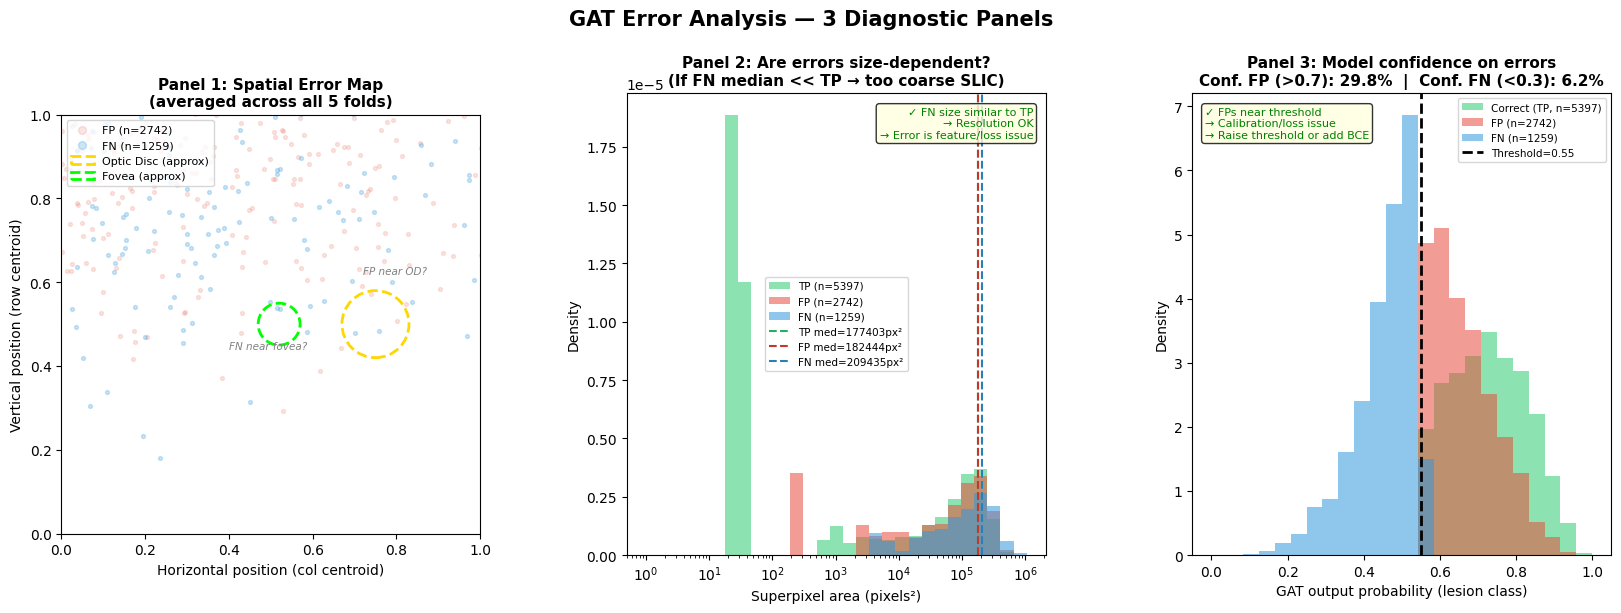


ERROR ANALYSIS INTERPRETATION

Panel 1 — Spatial:
  FPs near optic disc region: 17 / 2742 (0.6%)
  FNs near fovea region:      5 / 1259 (0.4%)

Panel 2 — Size:
  Median area — TP: 177403  FP: 182444  FN: 209435 px²
  → Sizes comparable: resolution is not the bottleneck

Panel 3 — Confidence:
  Confidently wrong FPs (prob>0.7): 29.8%
  Confidently wrong FNs (prob<0.3): 6.2%
  → Errors cluster near threshold → calibration/loss issue


In [ ]:
# ── NEW CELL: 3-Panel Error Analysis ────────────────────────

import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

print("Generating Error Analysis figure...")

fig = plt.figure(figsize=(20, 6))
fig.suptitle("GAT Error Analysis — 3 Diagnostic Panels", fontsize=15, fontweight='bold', y=1.02)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: Spatial distribution of FP and FN ──────────────
ax1 = fig.add_subplot(gs[0])

fp_df = error_df[error_df["outcome"] == "FP"]
fn_df = error_df[error_df["outcome"] == "FN"]
tp_df = error_df[error_df["outcome"] == "TP"]

# Plot as scatter on a blank canvas [0,1] x [0,1]
# cc = x-axis (column = horizontal), cr = y-axis (row = vertical, flip so top=0)
ax1.scatter(fp_df["cc"], 1 - fp_df["cr"], alpha=0.15, s=8,
            color="#e74c3c", label=f"FP (n={len(fp_df)})", rasterized=True)
ax1.scatter(fn_df["cc"], 1 - fn_df["cr"], alpha=0.25, s=8,
            color="#3498db", label=f"FN (n={len(fn_df)})", rasterized=True)

# Add optic disc approximate location marker (upper-right quadrant ~0.75, 0.5)
ax1.add_patch(plt.Circle((0.75, 0.5), 0.08, color='gold', fill=False,
                          linewidth=2, linestyle='--', label='Optic Disc (approx)'))
# Fovea/macula approximate location marker (center ~0.5, 0.5)
ax1.add_patch(plt.Circle((0.52, 0.5), 0.05, color='lime', fill=False,
                          linewidth=2, linestyle='--', label='Fovea (approx)'))

ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.set_xlabel("Horizontal position (col centroid)", fontsize=10)
ax1.set_ylabel("Vertical position (row centroid)", fontsize=10)
ax1.set_title("Panel 1: Spatial Error Map\n(averaged across all 5 folds)", fontsize=11, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, markerscale=2)
ax1.set_aspect('equal')

# Add quadrant labels
for txt, xy in [("FP near OD?", (0.72, 0.62)), ("FN near fovea?", (0.40, 0.44))]:
    ax1.annotate(txt, xy=xy, fontsize=7.5, color='gray', style='italic')

# ── Panel 2: Superpixel area distribution by outcome ─────────
ax2 = fig.add_subplot(gs[1])

tp_areas = tp_df["area"].values
fp_areas = fp_df["area"].values
fn_areas = fn_df["area"].values

# Use log scale since MA superpixels are tiny vs EX which are large
bins = np.logspace(np.log10(max(1, min(tp_areas.min(), fp_areas.min(), fn_areas.min()))),
                   np.log10(max(tp_areas.max(), fp_areas.max(), fn_areas.max())), 30)

ax2.hist(tp_areas, bins=bins, alpha=0.55, color="#2ecc71", label=f"TP (n={len(tp_df)})", density=True)
ax2.hist(fp_areas, bins=bins, alpha=0.55, color="#e74c3c", label=f"FP (n={len(fp_df)})", density=True)
ax2.hist(fn_areas, bins=bins, alpha=0.55, color="#3498db", label=f"FN (n={len(fn_df)})", density=True)

# Mark medians
for arr, color, label in [(tp_areas, "#27ae60", "TP med"),
                           (fp_areas, "#c0392b", "FP med"),
                           (fn_areas, "#2980b9", "FN med")]:
    med = np.median(arr)
    ax2.axvline(med, color=color, linestyle='--', linewidth=1.5,
                label=f"{label}={med:.0f}px²")

ax2.set_xscale('log')
ax2.set_xlabel("Superpixel area (pixels²)", fontsize=10)
ax2.set_ylabel("Density", fontsize=10)
ax2.set_title("Panel 2: Are errors size-dependent?\n(If FN median << TP → too coarse SLIC)", fontsize=11, fontweight='bold')
ax2.legend(fontsize=7.5)

# Annotation
fn_med = np.median(fn_areas)
tp_med = np.median(tp_areas)
if fn_med < tp_med * 0.7:
    msg = "⚠ FN SPs smaller than TP\n→ SLIC too coarse for MAs\n→ Use finer k=400 resolution"
    color_msg = "red"
else:
    msg = "✓ FN size similar to TP\n→ Resolution OK\n→ Error is feature/loss issue"
    color_msg = "green"
ax2.text(0.97, 0.97, msg, transform=ax2.transAxes, fontsize=8,
         va='top', ha='right', color=color_msg,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Panel 3: Confidence histogram for correct vs incorrect ───
ax3 = fig.add_subplot(gs[2])

correct_probs   = error_df[error_df["correct"] == 1]["prob"].values  # TP
incorrect_probs = error_df[error_df["correct"] == 0]["prob"].values  # FP + FN

# Split incorrect into FP and FN for more detail
fp_probs = fp_df["prob"].values
fn_probs = fn_df["prob"].values

bins_conf = np.linspace(0, 1, 25)

ax3.hist(correct_probs,   bins=bins_conf, alpha=0.55, color="#2ecc71",
         label=f"Correct (TP, n={len(correct_probs)})", density=True)
ax3.hist(fp_probs,        bins=bins_conf, alpha=0.55, color="#e74c3c",
         label=f"FP (n={len(fp_probs)})", density=True)
ax3.hist(fn_probs,        bins=bins_conf, alpha=0.55, color="#3498db",
         label=f"FN (n={len(fn_probs)})", density=True)

ax3.axvline(BEST_THRESH, color='black', linestyle='--', linewidth=2,
            label=f"Threshold={BEST_THRESH:.2f}")

# Compute % of FPs that are "confidently wrong" (prob > 0.7)
conf_fp_pct = 100 * (fp_probs > 0.7).sum() / max(len(fp_probs), 1)
conf_fn_pct = 100 * (fn_probs < 0.3).sum() / max(len(fn_probs), 1)

if conf_fp_pct > 40:
    msg3 = f"⚠ {conf_fp_pct:.0f}% FPs have prob>0.7\n→ Model confidently wrong\n→ Feature/graph topology issue"
    c3 = "red"
else:
    msg3 = f"✓ FPs near threshold\n→ Calibration/loss issue\n→ Raise threshold or add BCE"
    c3 = "green"

ax3.text(0.03, 0.97, msg3, transform=ax3.transAxes, fontsize=8,
         va='top', ha='left', color=c3,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax3.set_xlabel("GAT output probability (lesion class)", fontsize=10)
ax3.set_ylabel("Density", fontsize=10)
ax3.set_title(f"Panel 3: Model confidence on errors\n"
              f"Conf. FP (>0.7): {conf_fp_pct:.1f}%  |  Conf. FN (<0.3): {conf_fn_pct:.1f}%",
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("/content/error_analysis_3panel.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Print textual interpretation ──────────────────────────────
print("\n" + "="*60)
print("ERROR ANALYSIS INTERPRETATION")
print("="*60)
print(f"\nPanel 1 — Spatial:")
fp_near_od  = ((fp_df["cc"] > 0.65) & (fp_df["cr"].between(0.40, 0.60))).sum()
fn_near_fov = ((fn_df["cc"].between(0.42, 0.62)) & (fn_df["cr"].between(0.42, 0.62))).sum()
print(f"  FPs near optic disc region: {fp_near_od} / {len(fp_df)} "
      f"({100*fp_near_od/max(len(fp_df),1):.1f}%)")
print(f"  FNs near fovea region:      {fn_near_fov} / {len(fn_df)} "
      f"({100*fn_near_fov/max(len(fn_df),1):.1f}%)")

print(f"\nPanel 2 — Size:")
print(f"  Median area — TP: {np.median(tp_areas):.0f}  "
      f"FP: {np.median(fp_areas):.0f}  FN: {np.median(fn_areas):.0f} px²")
if fn_med < tp_med * 0.7:
    print("  → FNs are systematically smaller: ADD finer superpixel scale (k=400)")
else:
    print("  → Sizes comparable: resolution is not the bottleneck")

print(f"\nPanel 3 — Confidence:")
print(f"  Confidently wrong FPs (prob>0.7): {conf_fp_pct:.1f}%")
print(f"  Confidently wrong FNs (prob<0.3): {conf_fn_pct:.1f}%")
if conf_fp_pct > 40:
    print("  → Model is confidently wrong → fix features or graph topology")
else:
    print("  → Errors cluster near threshold → calibration/loss issue")

In [ ]:
# ── CELL 24: Run evaluation ──────────────────────────────────

all_idrid_eval_df = pd.concat([idrid_eval, idrid_test_eval], ignore_index=True)
all_idrid_eval_df = all_idrid_eval_df[
    all_idrid_eval_df["has_image"] & all_idrid_eval_df["has_any_mask"]
].reset_index(drop=True)
print(f"Evaluating {len(all_idrid_eval_df)} total images")
print(f"Evaluating with threshold = {BEST_THRESH:.2f}\n")
gt_all_results = []
for _, row in tqdm(all_idrid_eval_df.iterrows(), total=len(all_idrid_eval_df)):
    print(f"\n── {row['img_id']} ──")
    res = evaluate_one_image(row, gt_model, threshold=BEST_THRESH,
                             device=DEVICE, verbose=True)
    if res is not None:
        gt_all_results.append(res)

print(f"\n✅ Evaluated {len(gt_all_results)} images")

Evaluating 81 total images
Evaluating with threshold = 0.55



  0%|          | 0/81 [00:00<?, ?it/s]


── IDRiD_01 ──
   Probs: min=0.0007  max=0.9984  mean=0.3129  std=0.3666
   Threshold: 0.55 | Lesion SPs: 50/175 (28.6%)
   MA: Dice=0.003  IoU=0.002  Prec=0.002  Rec=0.781
   HE: Dice=0.014  IoU=0.007  Prec=0.007  Rec=0.858


  1%|          | 1/81 [00:04<05:51,  4.39s/it]

   EX: Dice=0.052  IoU=0.027  Prec=0.027  Rec=0.901

── IDRiD_02 ──
   Probs: min=0.0016  max=0.9998  mean=0.3931  std=0.4142
   Threshold: 0.55 | Lesion SPs: 55/154 (35.7%)
   MA: Dice=0.005  IoU=0.002  Prec=0.002  Rec=1.000
   HE: Dice=0.007  IoU=0.004  Prec=0.004  Rec=1.000


...

   EX: Dice=0.121  IoU=0.064  Prec=0.064  Rec=0.992

── IDRiD_80 ──
   Probs: min=0.0000  max=0.9991  mean=0.2969  std=0.3903
   Threshold: 0.55 | Lesion SPs: 48/167 (28.7%)
   MA: Dice=0.000  IoU=0.000  Prec=0.000  Rec=1.000
   HE: Dice=0.004  IoU=0.002  Prec=0.002  Rec=0.669


 99%|█████████▉| 80/81 [04:41<00:03,  3.30s/it]

   EX: Dice=0.004  IoU=0.002  Prec=0.002  Rec=1.000

── IDRiD_81 ──
   Probs: min=0.0002  max=0.9992  mean=0.4126  std=0.4197
   Threshold: 0.55 | Lesion SPs: 74/184 (40.2%)
   MA: Dice=0.006  IoU=0.003  Prec=0.003  Rec=0.899
   HE: Dice=0.013  IoU=0.007  Prec=0.007  Rec=0.860


100%|██████████| 81/81 [04:45<00:00,  3.52s/it]

   EX: Dice=0.104  IoU=0.055  Prec=0.055  Rec=0.955

✅ Evaluated 81 images


In [ ]:
# ── CELL NEW (REPLACEMENT): Visualise with DR grade label ────

# IDRiD has its own grading file — if you have it, use it.
# Otherwise we infer grade from which lesion masks exist:
def infer_idrid_grade(row):
    """Infer DR grade from which lesion types exist in IDRiD."""
    has = {lt: (row.get(f"mask_{lt}", "") != "") for lt in LESION_TYPES}
    if has["MA"] and not has["HE"] and not has["EX"] and not has["SE"]:
        return 1, "Mild DR"
    elif has["HE"] or has["EX"]:
        if has["SE"]:
            return 4, "Proliferative DR"
        elif has["HE"] and has["EX"]:
            return 3, "Severe DR"
        else:
            return 2, "Moderate DR"
    elif has["MA"]:
        return 1, "Mild DR"
    else:
        return 0, "No DR"

# Build grade lookup from idrid_eval
# REPLACE WITH:
idrid_grade_lookup = {}
for _, row in idrid_eval.iterrows():
    grade_num, grade_name = infer_idrid_grade(row)
    idrid_grade_lookup[row["img_id"]] = (grade_num, grade_name)
# Add test set images
if 'idrid_test_eval' in dir() and idrid_test_eval is not None:
    for _, row in idrid_test_eval.iterrows():
        grade_num, grade_name = infer_idrid_grade(row)
        idrid_grade_lookup[row["img_id"]] = (grade_num, grade_name)
print(f"Grade lookup now covers {len(idrid_grade_lookup)} images")


GRADE_COLORS = {
    0: "#2ecc71",   # green
    1: "#f1c40f",   # yellow
    2: "#e67e22",   # orange
    3: "#e74c3c",   # red
    4: "#8e44ad",   # purple
}

def visualize_lesion_overlay(result, save=False, idrid_grade_lookup=idrid_grade_lookup):
    orig      = result["orig"]
    pred_px   = result["pred_pixel"]
    img_id    = result["img_id"]

    orig_resized = cv2.resize(orig, (512, 512))

    overlay = orig_resized.copy().astype(np.float32)
    lesion_mask = pred_px.astype(bool)
    overlay[lesion_mask, 0] = np.clip(overlay[lesion_mask, 0] * 0.5 + 180, 0, 255)
    overlay[lesion_mask, 1] = np.clip(overlay[lesion_mask, 1] * 0.4, 0, 255)
    overlay[lesion_mask, 2] = np.clip(overlay[lesion_mask, 2] * 0.4, 0, 255)
    overlay = overlay.astype(np.uint8)
    blended = cv2.addWeighted(orig_resized, 0.6, overlay, 0.4, 0)

    # Get DR grade
    grade_num, grade_name = idrid_grade_lookup.get(img_id, (None, "Unknown"))
    grade_color = GRADE_COLORS.get(grade_num, "white")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Grade badge in title
    grade_label = f"Grade {grade_num}: {grade_name}" if grade_num is not None else "Grade: Unknown"

    axes[0].imshow(orig_resized)
    axes[0].set_title(f"Original — {img_id}\n{grade_label}", fontsize=11,
                      color=grade_color, fontweight='bold')
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"Predicted Lesions (red)\n{grade_label}", fontsize=11,
                      color=grade_color, fontweight='bold')
    axes[1].axis("off")

    axes[2].imshow(pred_px, cmap="hot")
    axes[2].set_title(f"Lesion Mask\n({result['n_lesion_sp']} lesion SPs)", fontsize=11)
    axes[2].axis("off")

    # Add colored grade patch in corner
    from matplotlib.patches import FancyBboxPatch
    for ax in axes[:2]:
        ax.add_patch(FancyBboxPatch((5, 5), 200, 35, boxstyle="round,pad=3",
                                    facecolor=grade_color, alpha=0.85,
                                    transform=ax.transData, zorder=5))
        ax.text(105, 23, grade_label, ha='center', va='center',
                fontsize=9, color='white', fontweight='bold',
                transform=ax.transData, zorder=6)

    plt.tight_layout()
    if save:
        plt.savefig(f"/content/{img_id}_lesion_overlay.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   {img_id} | {grade_label} | lesion SPs: {result['n_lesion_sp']}")

Grade lookup now covers 81 images


FINAL TEST EVALUATION — 8 held-out images
Threshold: 0.55

── IDRiD_24 ──
   Probs: min=0.0001  max=0.9991  mean=0.3557  std=0.4151
   Threshold: 0.55 | Lesion SPs: 70/199 (35.2%)
   MA: Dice=0.001  IoU=0.000  Prec=0.000  Rec=1.000
   HE: Dice=0.009  IoU=0.004  Prec=0.004  Rec=1.000
   EX: Dice=0.004  IoU=0.002  Prec=0.002  Rec=0.982
   SP-level → Prec=0.309  Rec=1.000  F1=0.472  IoU=0.309

── IDRiD_75 ──
   Probs: min=0.0003  max=0.9993  mean=0.3749  std=0.4101
   Threshold: 0.55 | Lesion SPs: 56/164 (34.1%)
   MA: Dice=0.012  IoU=0.006  Prec=0.006  Rec=0.901
   HE: Dice=0.041  IoU=0.021  Prec=0.021  Rec=0.841
   EX: Dice=0.009  IoU=0.005  Prec=0.005  Rec=0.886
   SE: Dice=0.004  IoU=0.002  Prec=0.002  Rec=0.771
   SP-level → Prec=0.886  Rec=0.886  F1=0.886  IoU=0.795

── IDRiD_76 ──
   Probs: min=0.0000  max=0.9994  mean=0.3637  std=0.4098
   Threshold: 0.55 | Lesion SPs: 60/178 (33.7%)
   MA: Dice=0.012  IoU=0.006  Prec=0.006  Rec=0.873
   HE: Dice=0.026  IoU=0.013  Prec=0.013  Rec=

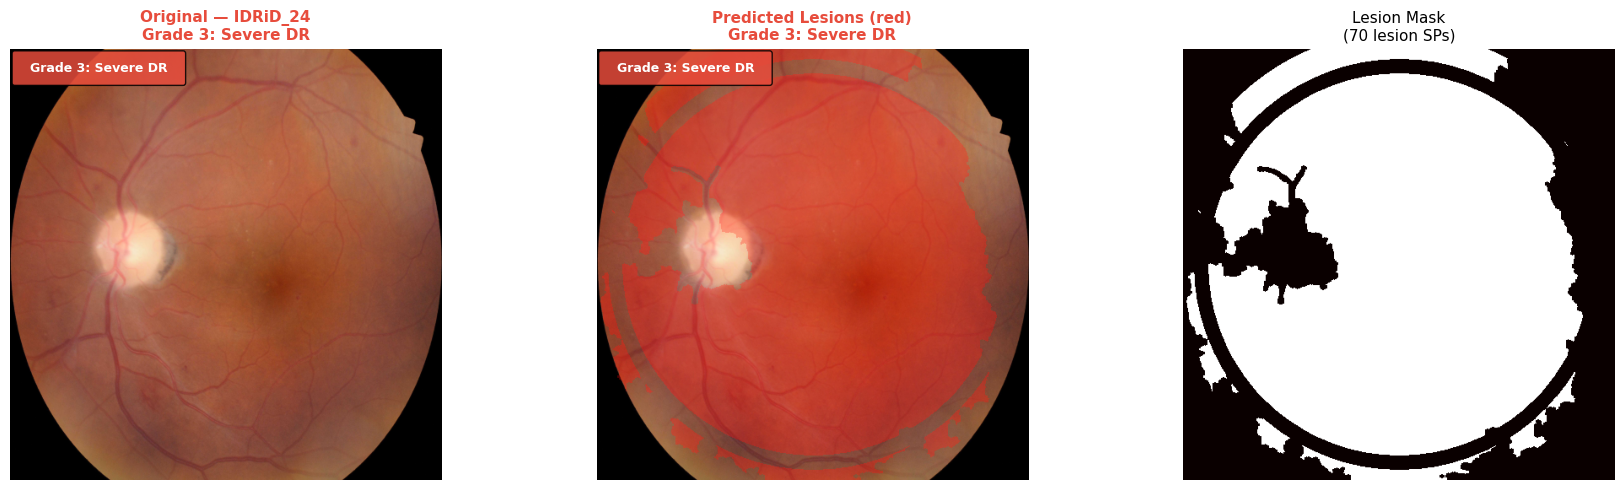

   IDRiD_24 | Grade 3: Severe DR | lesion SPs: 70


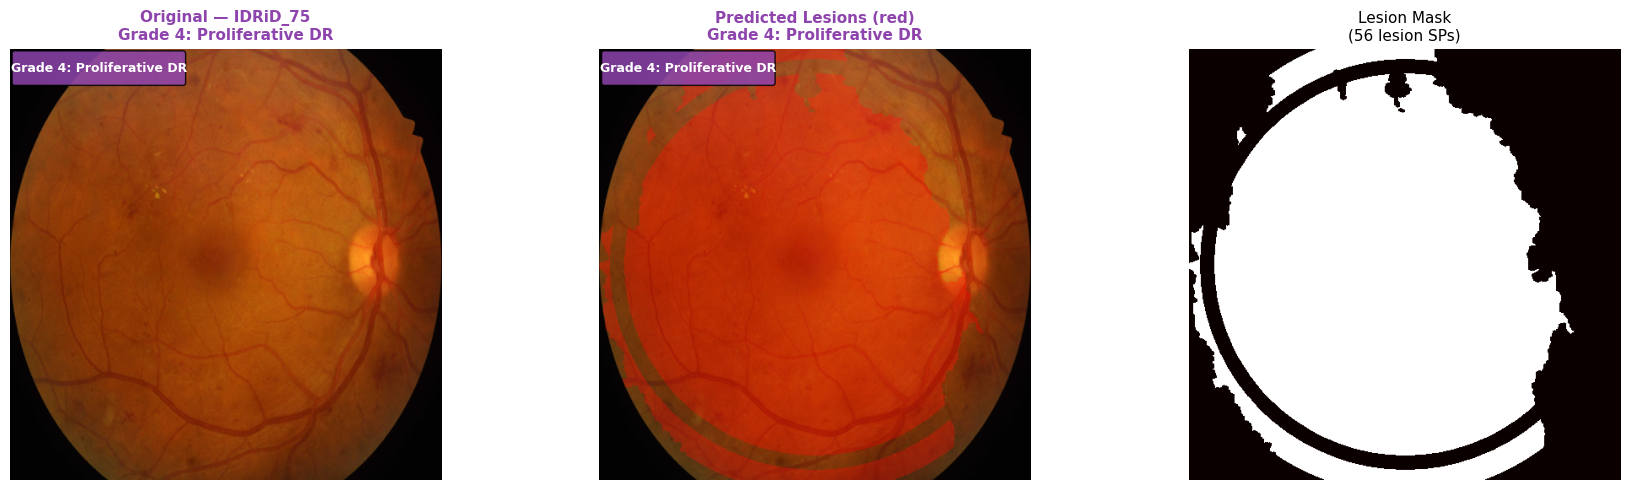

   IDRiD_75 | Grade 4: Proliferative DR | lesion SPs: 56


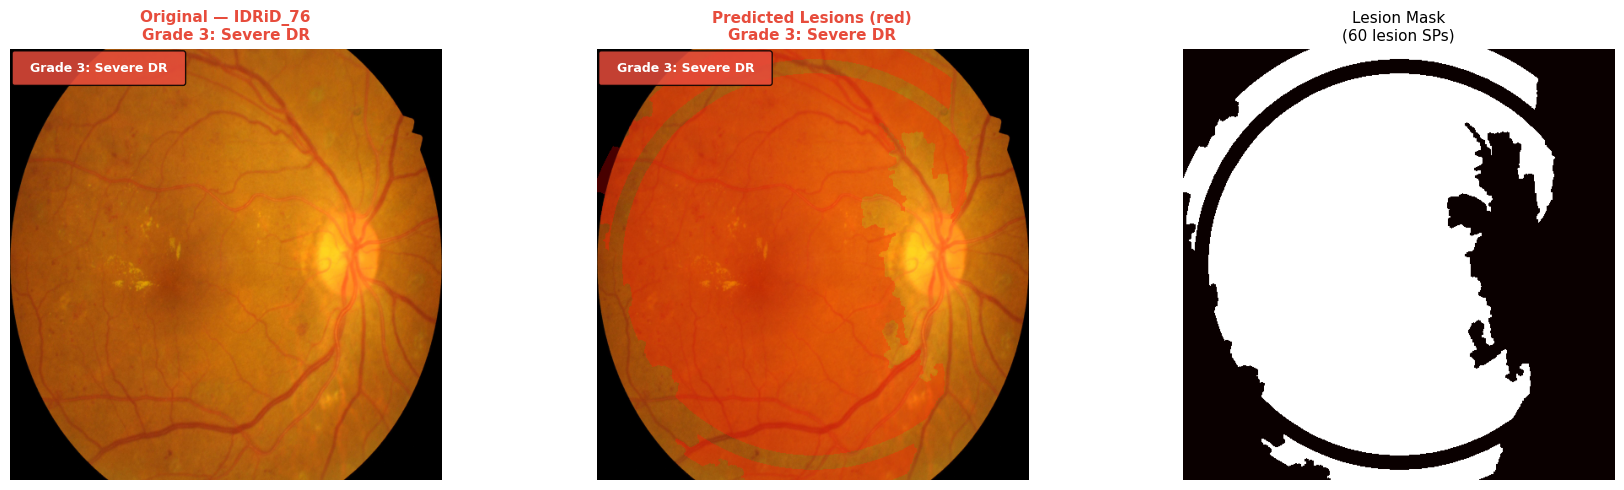

   IDRiD_76 | Grade 3: Severe DR | lesion SPs: 60


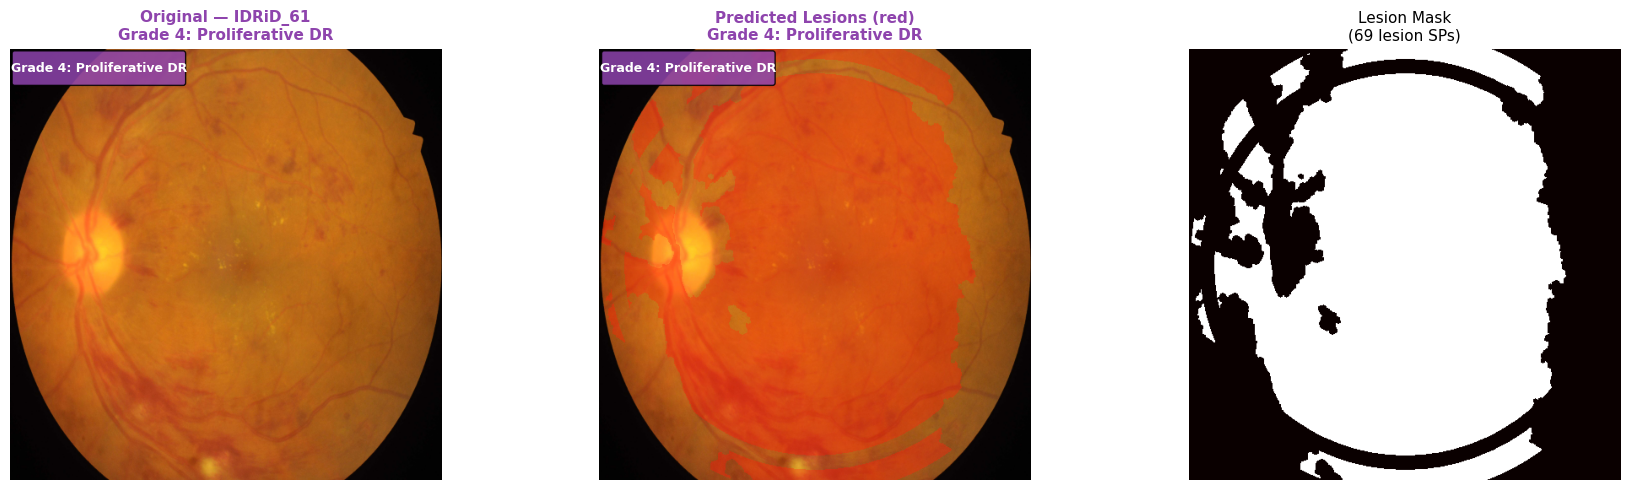

   IDRiD_61 | Grade 4: Proliferative DR | lesion SPs: 69


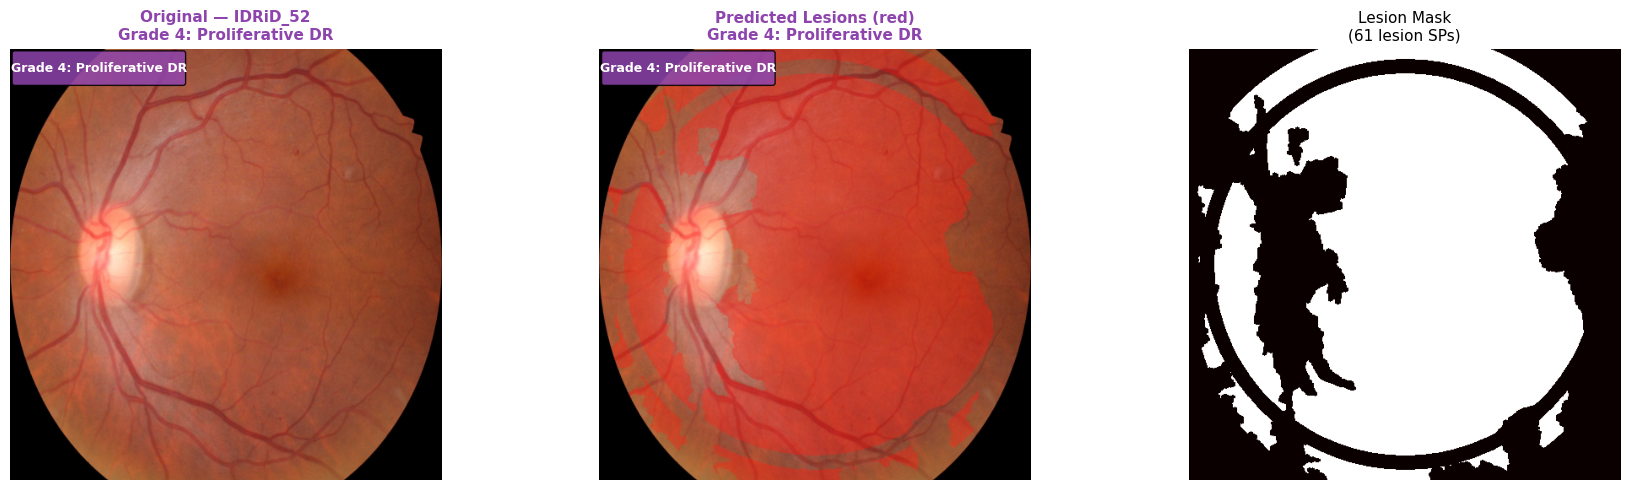

   IDRiD_52 | Grade 4: Proliferative DR | lesion SPs: 61


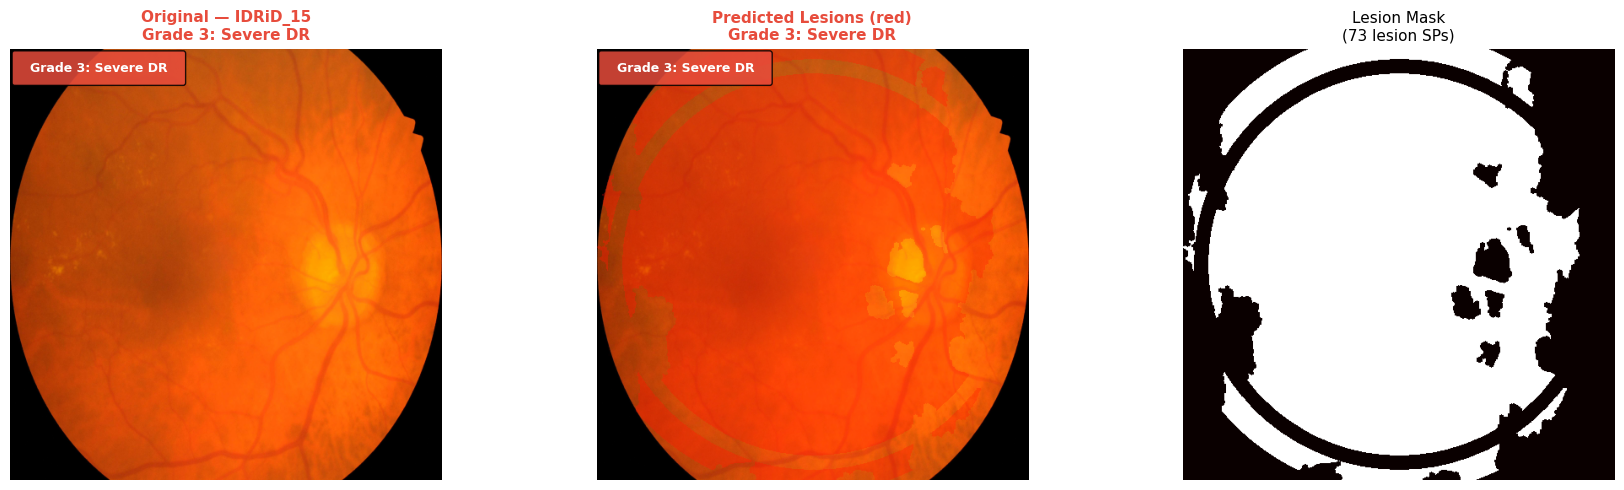

   IDRiD_15 | Grade 3: Severe DR | lesion SPs: 73


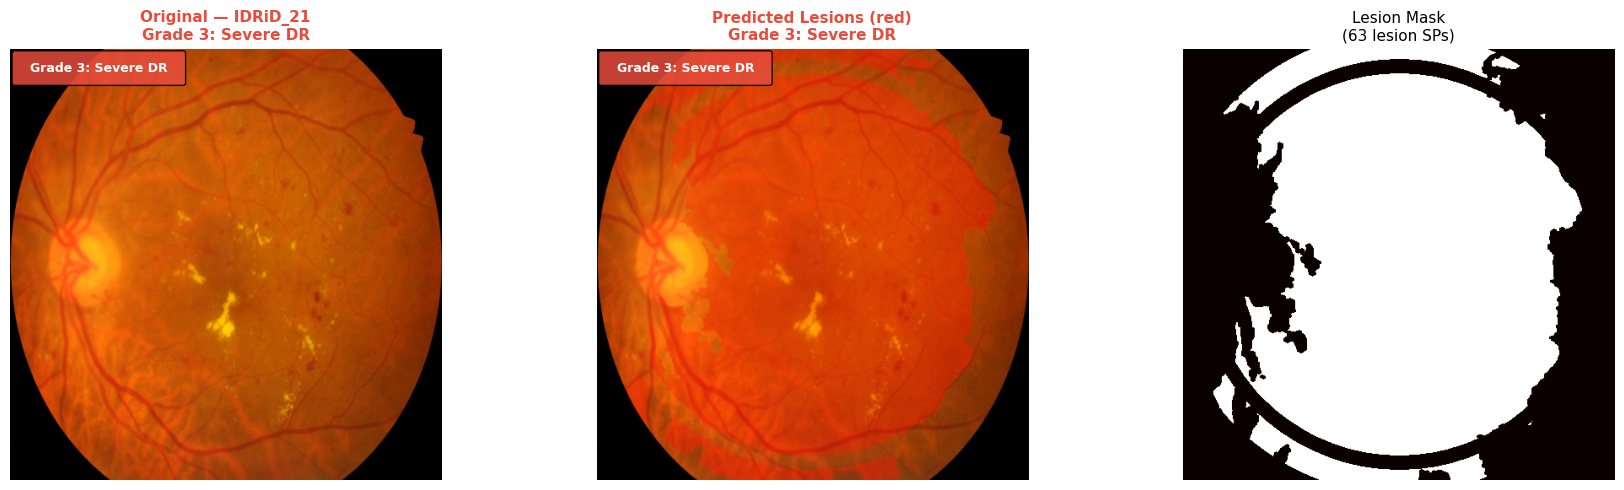

   IDRiD_21 | Grade 3: Severe DR | lesion SPs: 63


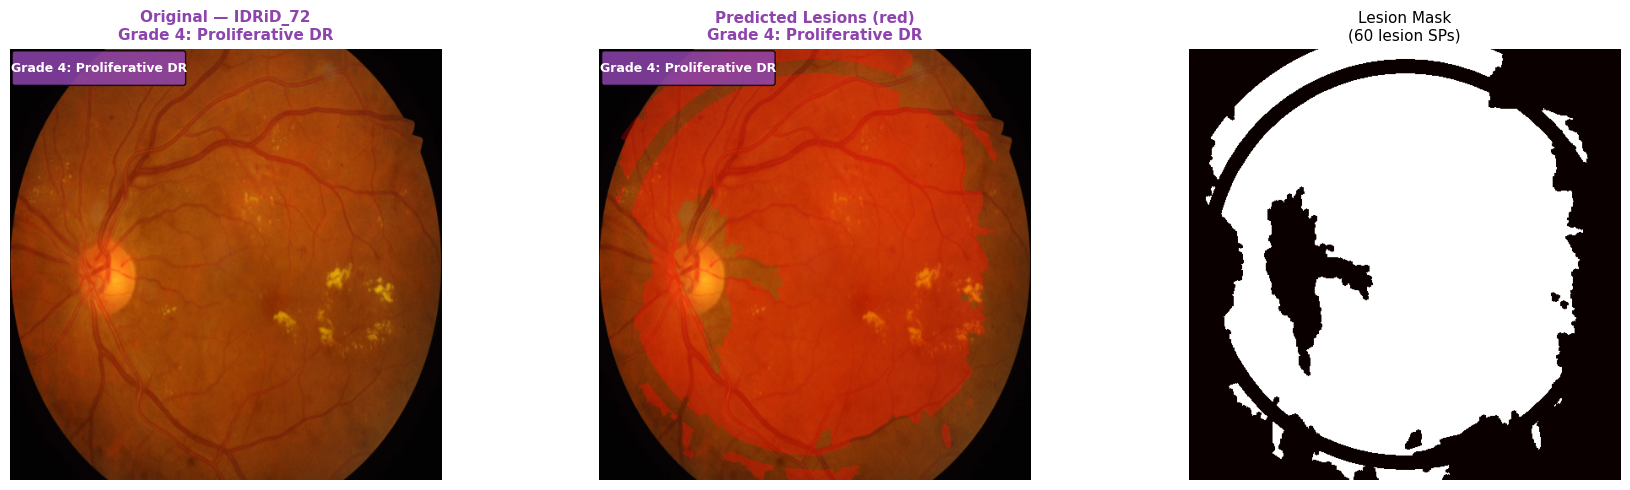

   IDRiD_72 | Grade 4: Proliferative DR | lesion SPs: 60


In [ ]:
# ── NEW CELL: Final evaluation on held-out 8 test images ─────

print("="*60)
print(f"FINAL TEST EVALUATION — {len(test_graphs)} held-out images")
print(f"Threshold: {BEST_THRESH:.2f}")
print("="*60)

# Build a lookup from img_id → row in all_idrid_eval_df for mask paths
eval_row_lookup = {row["img_id"]: row
                   for _, row in all_idrid_eval_df.iterrows()}

gt_model.eval()
test_results  = []
test_sp_rows  = []

for g in test_graphs:
    img_id = g.img_id
    print(f"\n── {img_id} ──")

    # Get the evaluation row (has mask paths)
    if img_id not in eval_row_lookup:
        print(f"   ⚠ No eval row found for {img_id}, skipping pixel metrics")
        continue

    row = eval_row_lookup[img_id]
    res = evaluate_one_image(row, gt_model,
                             threshold=BEST_THRESH,
                             device=DEVICE, verbose=True)
    if res is None:
        continue
    test_results.append(res)

    # SP-level metrics
    gg     = g.to(DEVICE)
    with torch.no_grad():
        logits   = gt_model(gg.x, gg.edge_index, gg.edge_attr)
        probs_np = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds_sp  = (probs_np > BEST_THRESH).astype(np.int64)
    labels_sp = g.y.cpu().numpy()

    TP = ((preds_sp==1)&(labels_sp==1)).sum()
    FP = ((preds_sp==1)&(labels_sp==0)).sum()
    FN = ((preds_sp==0)&(labels_sp==1)).sum()
    TN = ((preds_sp==0)&(labels_sp==0)).sum()
    prec = TP / (TP + FP + 1e-8)
    rec  = TP / (TP + FN + 1e-8)
    f1   = 2*TP / (2*TP + FP + FN + 1e-8)
    iou  = TP / (TP + FP + FN + 1e-8)
    spec = TN / (TN + FP + 1e-8)

    test_sp_rows.append({
        "img_id": img_id,
        "TP": int(TP), "FP": int(FP), "FN": int(FN),
        "Precision": round(float(prec), 4),
        "Recall":    round(float(rec),  4),
        "F1":        round(float(f1),   4),
        "IoU":       round(float(iou),  4),
        "Specificity": round(float(spec), 4),
    })
    print(f"   SP-level → Prec={prec:.3f}  Rec={rec:.3f}  "
          f"F1={f1:.3f}  IoU={iou:.3f}")

# ── Summary table ─────────────────────────────────────────────
test_sp_df = pd.DataFrame(test_sp_rows)
print("\n" + "="*60)
print("TEST SET SP-LEVEL SUMMARY")
print("="*60)
print(test_sp_df.to_string(index=False))
print("\nMean across test images:")
cols = ["Precision","Recall","F1","IoU","Specificity"]
print(test_sp_df[cols].mean().round(4).to_string())

# Visualize all test images
print("\nVisualizing test images...")
for res in test_results:
    visualize_lesion_overlay(res, save=True,
                             idrid_grade_lookup=idrid_grade_lookup)